<h1 style="text-align: center;">Exploratory Data Analysis</h1>
<h3 style="text-align: center;">Hotel Booking Cancellation Prediction</h3>

---

<h5 style="text-align: right;">By Beta Group</h5>


# **Section 0: Setup**

## **0.1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_ztest

## **0.2. Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv("../data/hotel_booking_2017_cleaned.csv")

In [3]:
num_cols = [
    "lead_time",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

cat_cols = [
    "hotel",
    "arrival_date_year",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "agent",
    "company",

    "has_children",
    "has_babies",
    "is_family",
    "has_agent",
    "has_company",
    "room_type_changed"
]

low_card_cols = [
    col for col in cat_cols
    if df[col].nunique() <= 15
]

high_card_cols = [
    col for col in cat_cols
    if df[col].nunique() > 15
]


# **Section 1: EDA**

## **1.1 Univariate Analysis**

### **1.1.1 Target Distribution (`is_canceled`)**

/var/folders/yw/tk12_1sj1856p7h5vkw1vjf40000gn/T/ipykernel_96796/3309304205.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Not Canceled", "Canceled"])


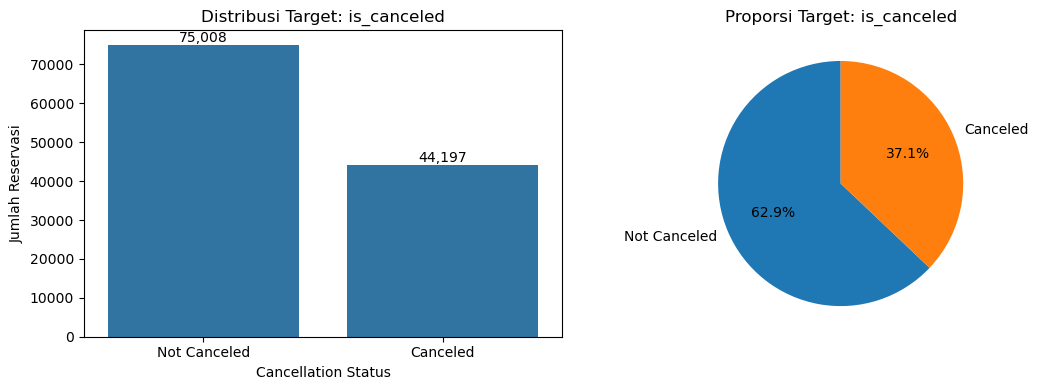

Jumlah Reservasi:
is_canceled
0    75008
1    44197
Name: count, dtype: int64

Persentase Reservasi:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64


In [4]:
# Target distribution
target_counts = df['is_canceled'].value_counts().sort_index()
target_pct = df['is_canceled'].value_counts(normalize=True).sort_index() * 100

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
sns.countplot(
    data=df,
    x='is_canceled',
    order=[0, 1],
    ax=ax[0]
)

ax[0].set_title("Distribusi Target: is_canceled")
ax[0].set_xlabel("Cancellation Status")
ax[0].set_ylabel("Jumlah Reservasi")
ax[0].set_xticklabels(["Not Canceled", "Canceled"])

# Menambahkan jumlah pada bar
for p in ax[0].patches:
    ax[0].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Pie chart
ax[1].pie(
    target_pct,
    labels=["Not Canceled", "Canceled"],
    autopct='%1.1f%%',
    startangle=90
)

ax[1].set_title("Proporsi Target: is_canceled")

plt.tight_layout()
plt.show()

# Menampilkan hasil
print("Jumlah Reservasi:")
print(target_counts)

print("\nPersentase Reservasi:")
print(target_pct.round(2))

#### Target Distribution Insight

- **Target `is_canceled` terdiri atas 75.008 booking Not Canceled (62,92%) dan 44.197 booking Canceled (37,08%).** Dengan demikian, hampir 4 dari 10 reservasi dalam dataset berakhir dibatalkan.

- **Imbalance ratio sebesar 1,70:1 menunjukkan mild class imbalance.** Distribusi ini belum termasuk ketidakseimbangan ekstrem.

- **Modeling Implication:** evaluasi model tidak cukup menggunakan accuracy. ROC-AUC dapat digunakan untuk membandingkan kemampuan pemeringkatan model, kemudian threshold dapat dioptimalkan menggunakan F1-score serta diperiksa melalui precision, recall, dan confusion matrix.

- **Business Implication:** cancellation rate sebesar 37,08% menunjukkan bahwa pembatalan merupakan masalah material. Kemampuan mengidentifikasi booking berisiko dapat mendukung perencanaan okupansi, pengelolaan inventori kamar, dan perlindungan pendapatan.


### **1.1.2 Numerical Feature Distribution**

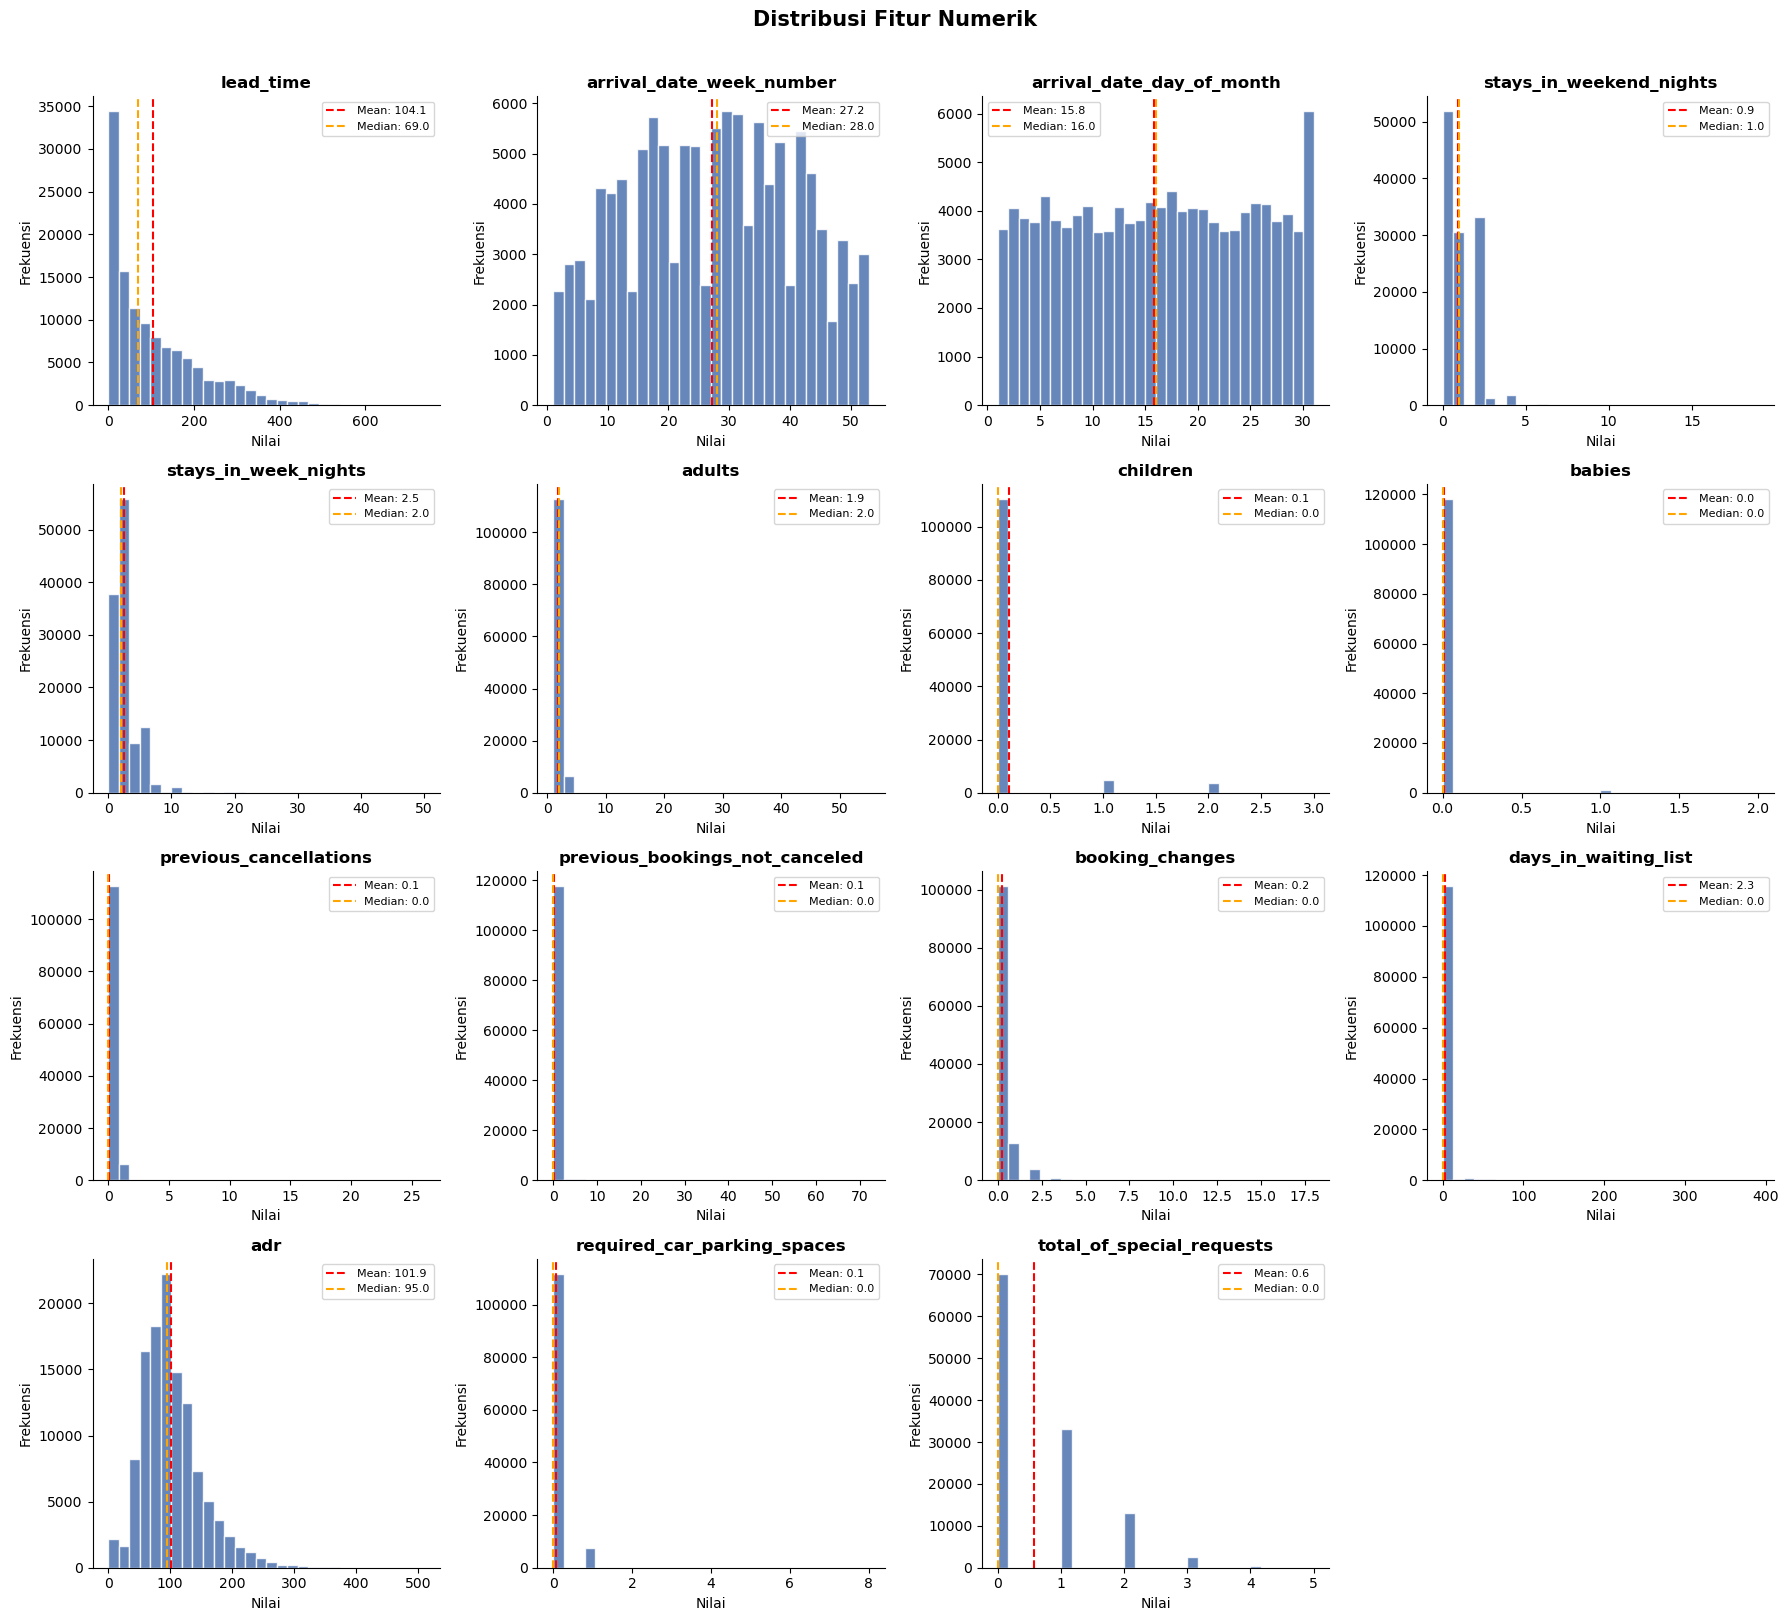

In [5]:
n = len(num_cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

# matikan axes sisa yang tidak dipakai
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [6]:
skew_df = pd.DataFrame({
    'Mean':     df[num_cols].mean().round(2),
    'Median':   df[num_cols].median().round(2),
    'Std':      df[num_cols].std().round(2),
    'Min':      df[num_cols].min().round(2),
    'Max':      df[num_cols].max().round(2),
    'Skewness': df[num_cols].skew().round(3)
})
display(skew_df)

,Mean,Median,Std,Min,Max,Skewness
lead_time,104.11,69.00,106.88,0.0,737.0,1.346
arrival_date_week_number,27.16,28.00,13.60,1.0,53.0,-0.010
arrival_date_day_of_month,15.80,16.00,8.78,1.0,31.0,-0.002
stays_in_weekend_nights,0.93,1.00,1.00,0.0,19.0,1.320
stays_in_week_nights,2.50,2.00,1.90,0.0,50.0,2.755
adults,1.86,2.00,0.57,1.0,55.0,19.265
children,0.10,0.00,0.40,0.0,3.0,4.012
babies,0.01,0.00,0.09,0.0,2.0,11.713
previous_cancellations,0.09,0.00,0.84,0.0,26.0,24.443
previous_bookings_not_canceled,0.14,0.00,1.50,0.0,72.0,23.540


#### Numerical Feature Distribution Insight

- **Sebagian besar fitur numerik memiliki distribusi right-skewed**, terutama `previous_cancellations` (24,443), `previous_bookings_not_canceled` (23,540), `adults` (19,265), `days_in_waiting_list` (11,949), dan `babies` (11,713). Sebaliknya, `arrival_date_week_number` (-0,010) dan `arrival_date_day_of_month` (-0,002) relatif simetris.

- **Beberapa fitur merupakan count data yang sangat terkonsentrasi pada nol.** Pola ini terlihat pada `children`, `babies`, `previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes`, dan `days_in_waiting_list`, sehingga mean kurang representatif apabila digunakan tanpa melihat median dan distribusinya.

- **`lead_time` dan `adr` menunjukkan right-skewness moderat**, masing-masing sebesar 1,346 dan 1,030. Pada output terbaru, `lead_time` berada pada rentang 0–737 hari, sedangkan `adr` berada pada rentang 0–510.

- **Modeling Implication:** fitur yang skewed dan memiliki nilai ekstrem perlu ditangani sesuai model yang digunakan. `RobustScaler` dapat dipertimbangkan untuk model linear yang sensitif terhadap skala, sedangkan model berbasis pohon pada umumnya tidak memerlukan scaling.


### **1.1.3 Categorical Feature Distribution**

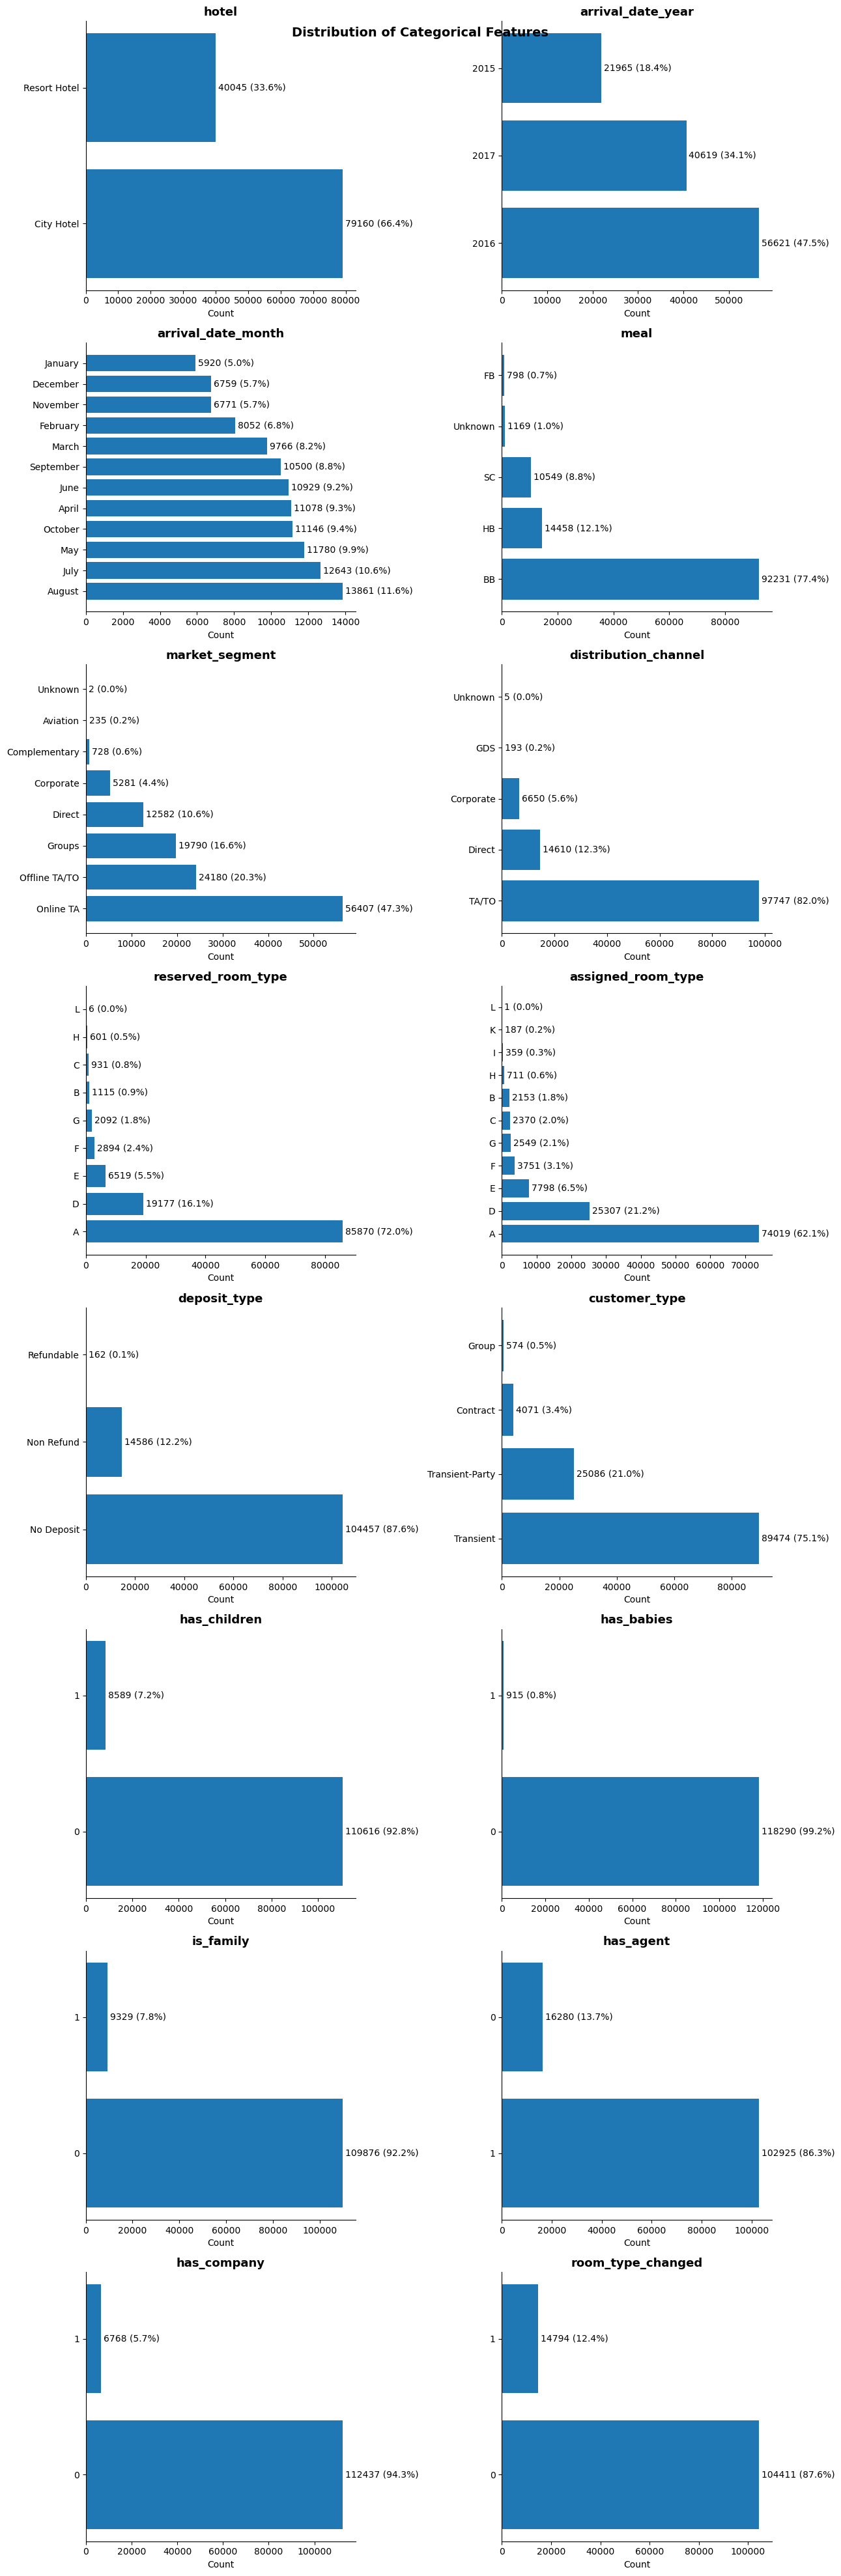

In [7]:
n_cols = 2
n_rows = math.ceil(len(low_card_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(13, 5 * n_rows)
)

axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, low_card_cols):

    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100

    bars = ax.barh(
        counts.index.astype(str),
        counts.values
    )

    for bar, (v, p) in zip(
        bars,
        zip(counts.values, pcts.values)
    ):
        ax.text(
            v + counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{v} ({p:.1f}%)",
            va="center"
        )

    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

for j in range(len(low_card_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

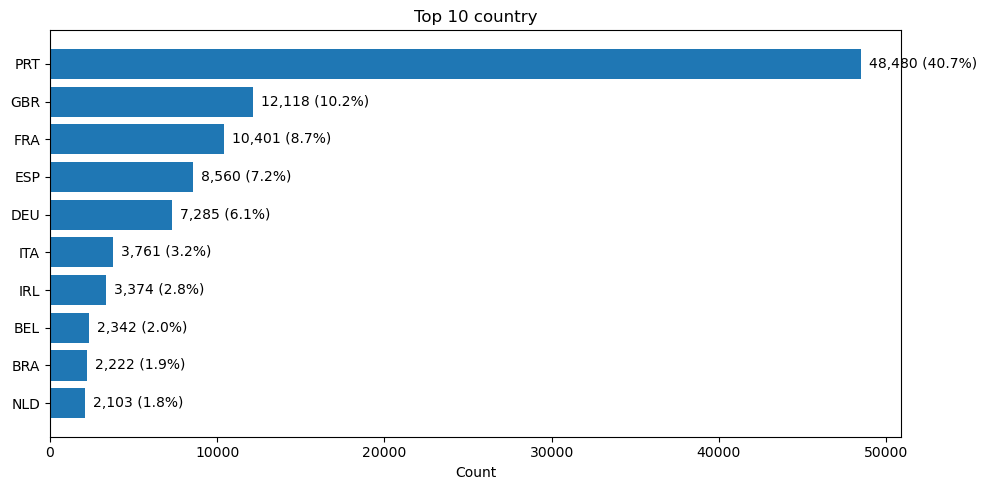

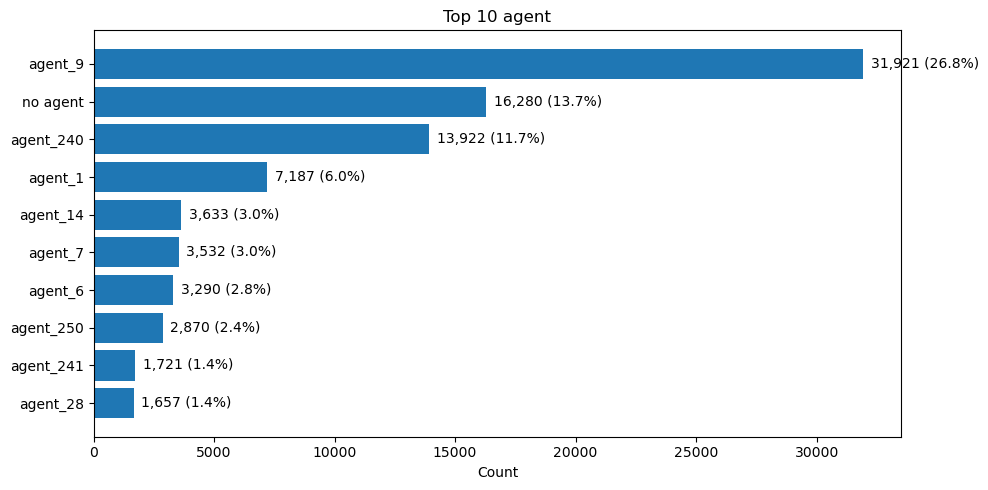

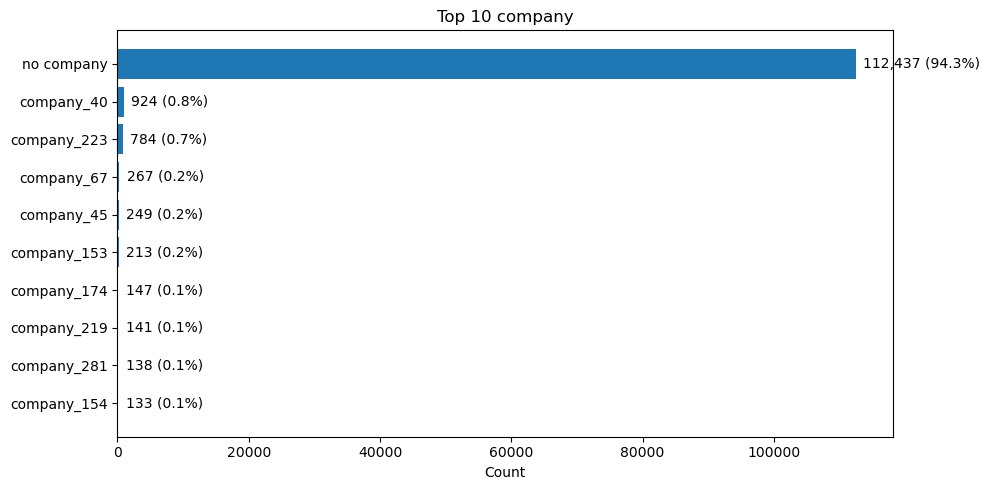

In [8]:
for col in high_card_cols:

    counts = df[col].value_counts().head(10)
    pcts = counts / len(df) * 100

    plt.figure(figsize=(10, 5))

    bars = plt.barh(
        counts.index.astype(str),
        counts.values
    )

    for bar, count, pct in zip(bars, counts.values, pcts.values):
        plt.text(
            count + counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,} ({pct:.1f}%)",
            va="center"
        )

    plt.title(f"Top 10 {col}")
    plt.xlabel("Count")

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

#### Categorical Feature Distribution Insight

- **Beberapa fitur kategorikal sangat terkonsentrasi pada satu kategori.** `deposit_type` didominasi No Deposit (87,6%), sedangkan `has_babies` (99,2% = 0), `has_children` (92,8% = 0), `is_family` (92,2% = 0), dan `has_company` (94,3% = 0) memiliki kategori minoritas yang relatif kecil.

- **Perbedaan `reserved_room_type` dan `assigned_room_type` menunjukkan perubahan alokasi kamar.** Room type A turun dari 72,0% pada kamar yang dipesan menjadi 62,1% pada kamar yang dialokasikan, selaras dengan 12,4% booking yang mengalami perubahan tipe kamar. `assigned_room_type` dan `room_type_changed` berpotensi menyebabkan leakage apabila baru tersedia setelah waktu prediksi.

- **`distribution_channel`, `market_segment`, dan `has_agent` berpotensi membawa informasi yang tumpang tindih.** TA/TO mencakup 82,0% booking, Online TA merupakan market segment terbesar (47,3%), dan 86,3% booking menggunakan agent. Hubungan ketiganya perlu diperiksa dengan crosstab atau ukuran asosiasi sebelum digunakan bersama.

- **`country`, `agent`, dan `company` memiliki high cardinality.** Sepuluh negara terbesar mencakup 84,6% booking dengan Portugal sebagai negara terbesar (40,7%). Agent 9 menyumbang 26,8% booking, sedangkan 94,3% booking tidak memiliki company. Kategori langka dapat dipertimbangkan untuk dikelompokkan menjadi `Other` berdasarkan data training.

- **Modeling Implication:** kode agent dan company harus diperlakukan sebagai kategori, bukan angka kontinu. Hindari memasukkan representasi yang duplikatif, misalnya `company` bersama `has_company`, tanpa mengevaluasi tambahan informasi yang diberikan.


## **1.2 Bivariate Analysis**
### **1.2.1 Numerical Features VS Target**

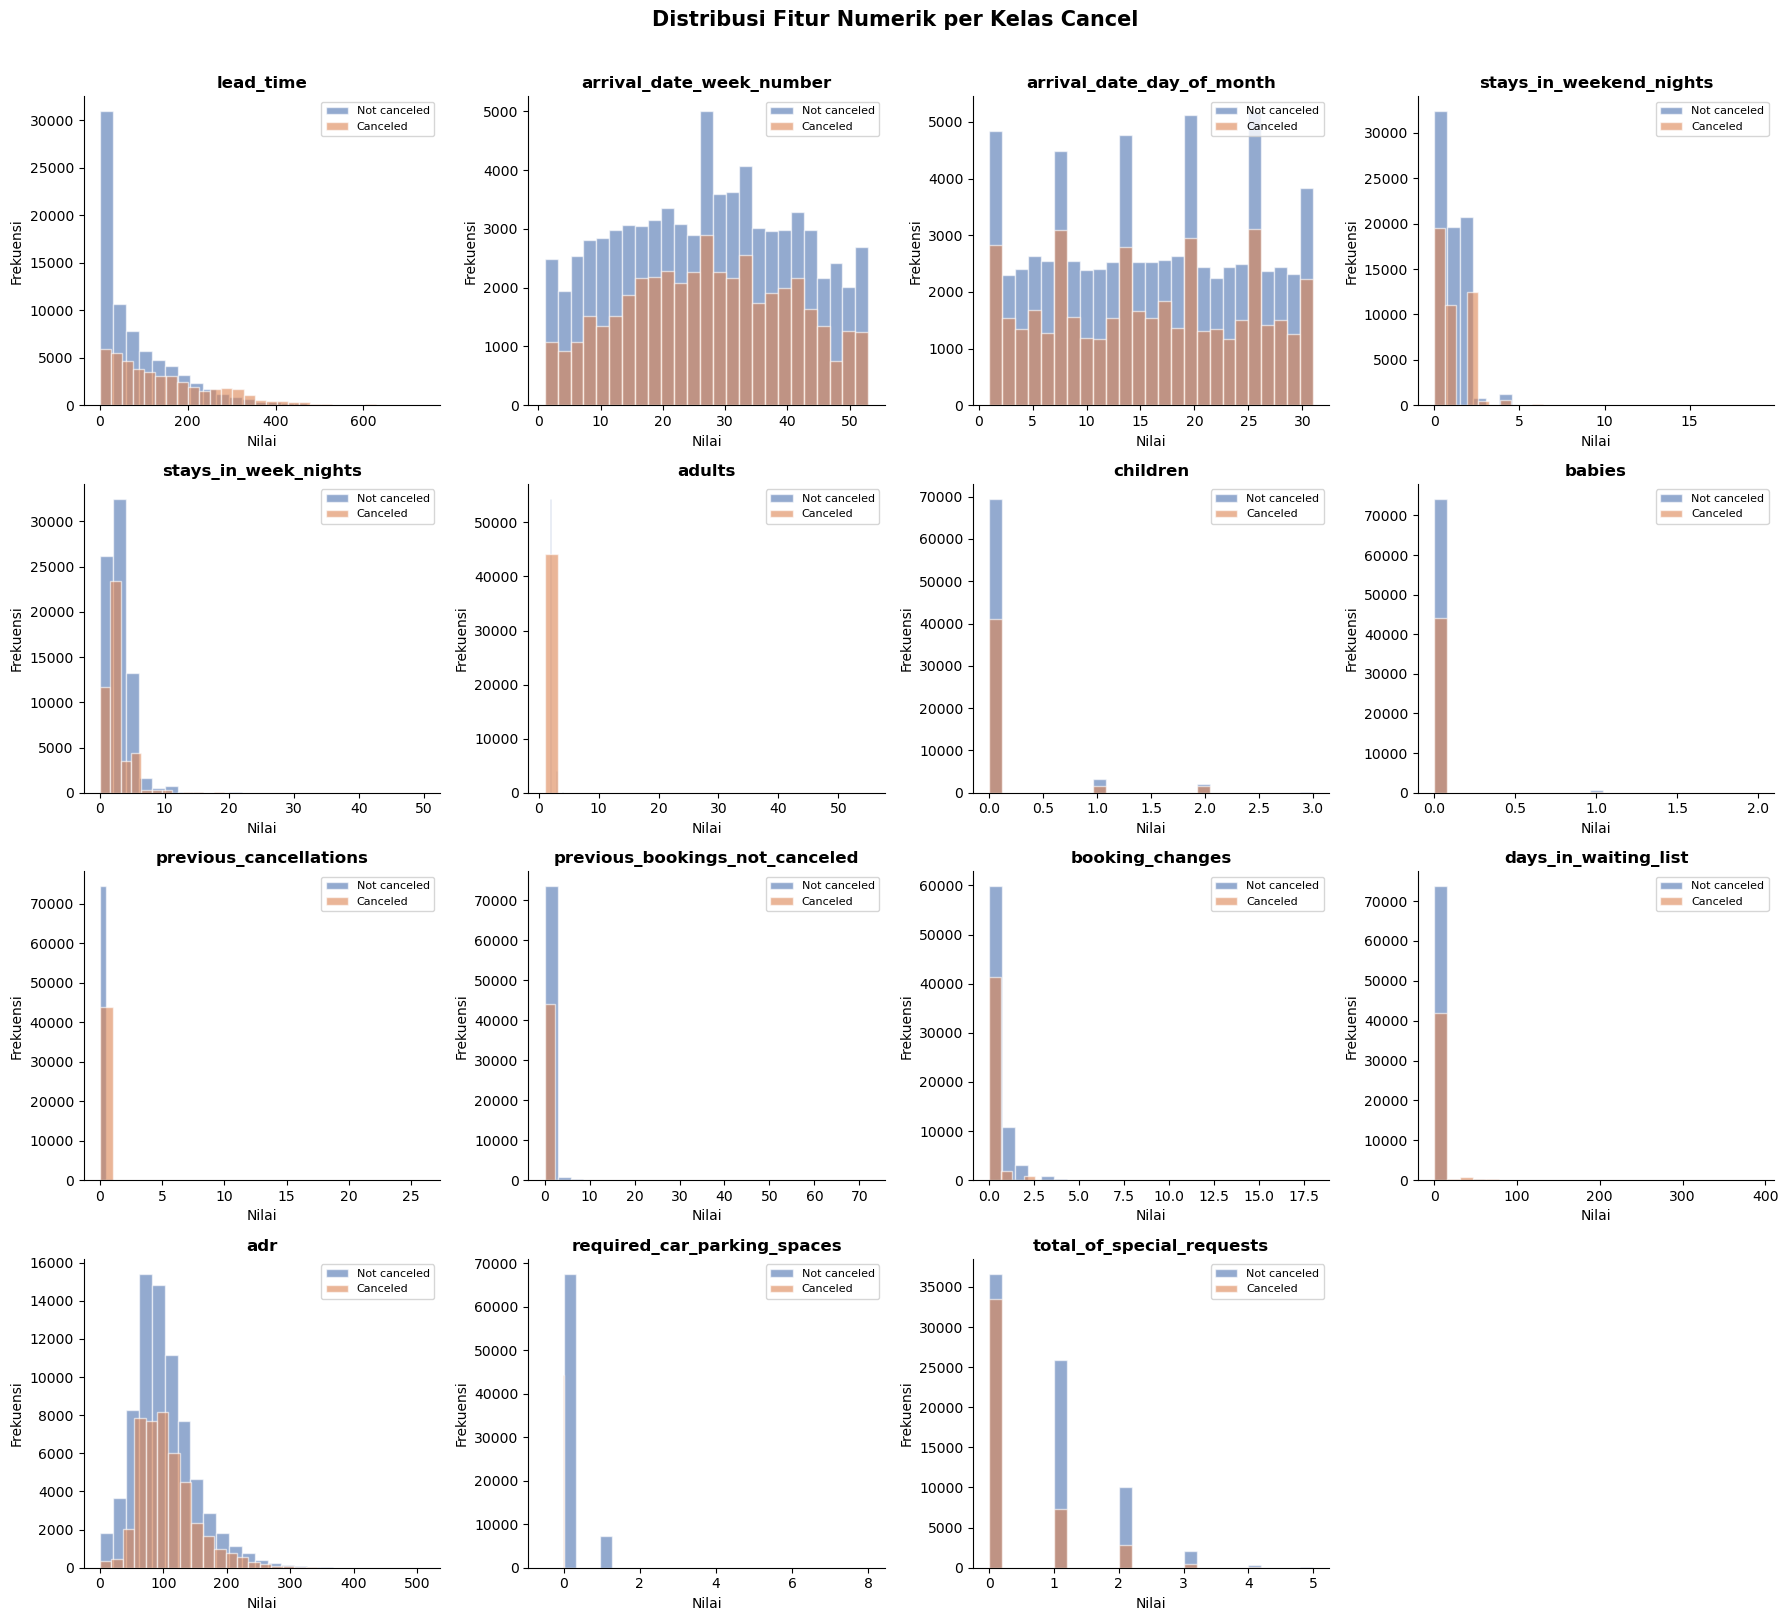

In [9]:
n = len(num_cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for cancel_val, label, color in zip([0, 1], ['Not canceled', 'Canceled'], ['#4C72B0', '#DD8452']):
        subset = df[df['is_canceled'] == cancel_val][col]
        ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# matikan axes sisa yang tidak dipakai
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik per Kelas Cancel', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Numerical Feature Distribution per Cancel Class Insight

- **`lead_time` menunjukkan pemisahan visual paling jelas.** Booking Not Canceled lebih terkonsentrasi pada lead time rendah, sedangkan distribusi Canceled lebih lebar dan memiliki ekor lebih tebal pada nilai tinggi. Hubungan ini tetap perlu dikonfirmasi dengan cancellation rate per bin dan uji statistik.

- **`total_of_special_requests` dan `required_car_parking_spaces` memberikan indikasi perbedaan antarkelas.** Booking Canceled lebih terkonsentrasi pada nilai nol, tetapi histogram menggunakan frekuensi mentah dan ukuran kedua kelas berbeda. Karena itu, tinggi batang tidak dapat langsung dibaca sebagai cancellation rate.

- **Fitur count yang zero-inflated**, seperti `previous_cancellations`, `previous_bookings_not_canceled`, `babies`, `days_in_waiting_list`, dan `booking_changes`, kurang informatif pada histogram keseluruhan. Analisis lanjutan sebaiknya membandingkan cancellation rate pada kelompok 0 dan >0 atau pada setiap kategori.

- **`arrival_date_week_number`, `arrival_date_day_of_month`, `adr`, dan jumlah malam menginap menunjukkan tumpang tindih yang cukup besar** antara kedua kelas pada skala ini. Histogram belum memberikan bukti pemisahan kuat untuk fitur-fitur tersebut.

- **Modeling Implication:** histogram ini merupakan eksplorasi awal, bukan ukuran feature importance. Gunakan density plot, cancellation rate per bin, boxplot, serta Mann–Whitney U dan effect size untuk membandingkan kelas secara lebih adil.


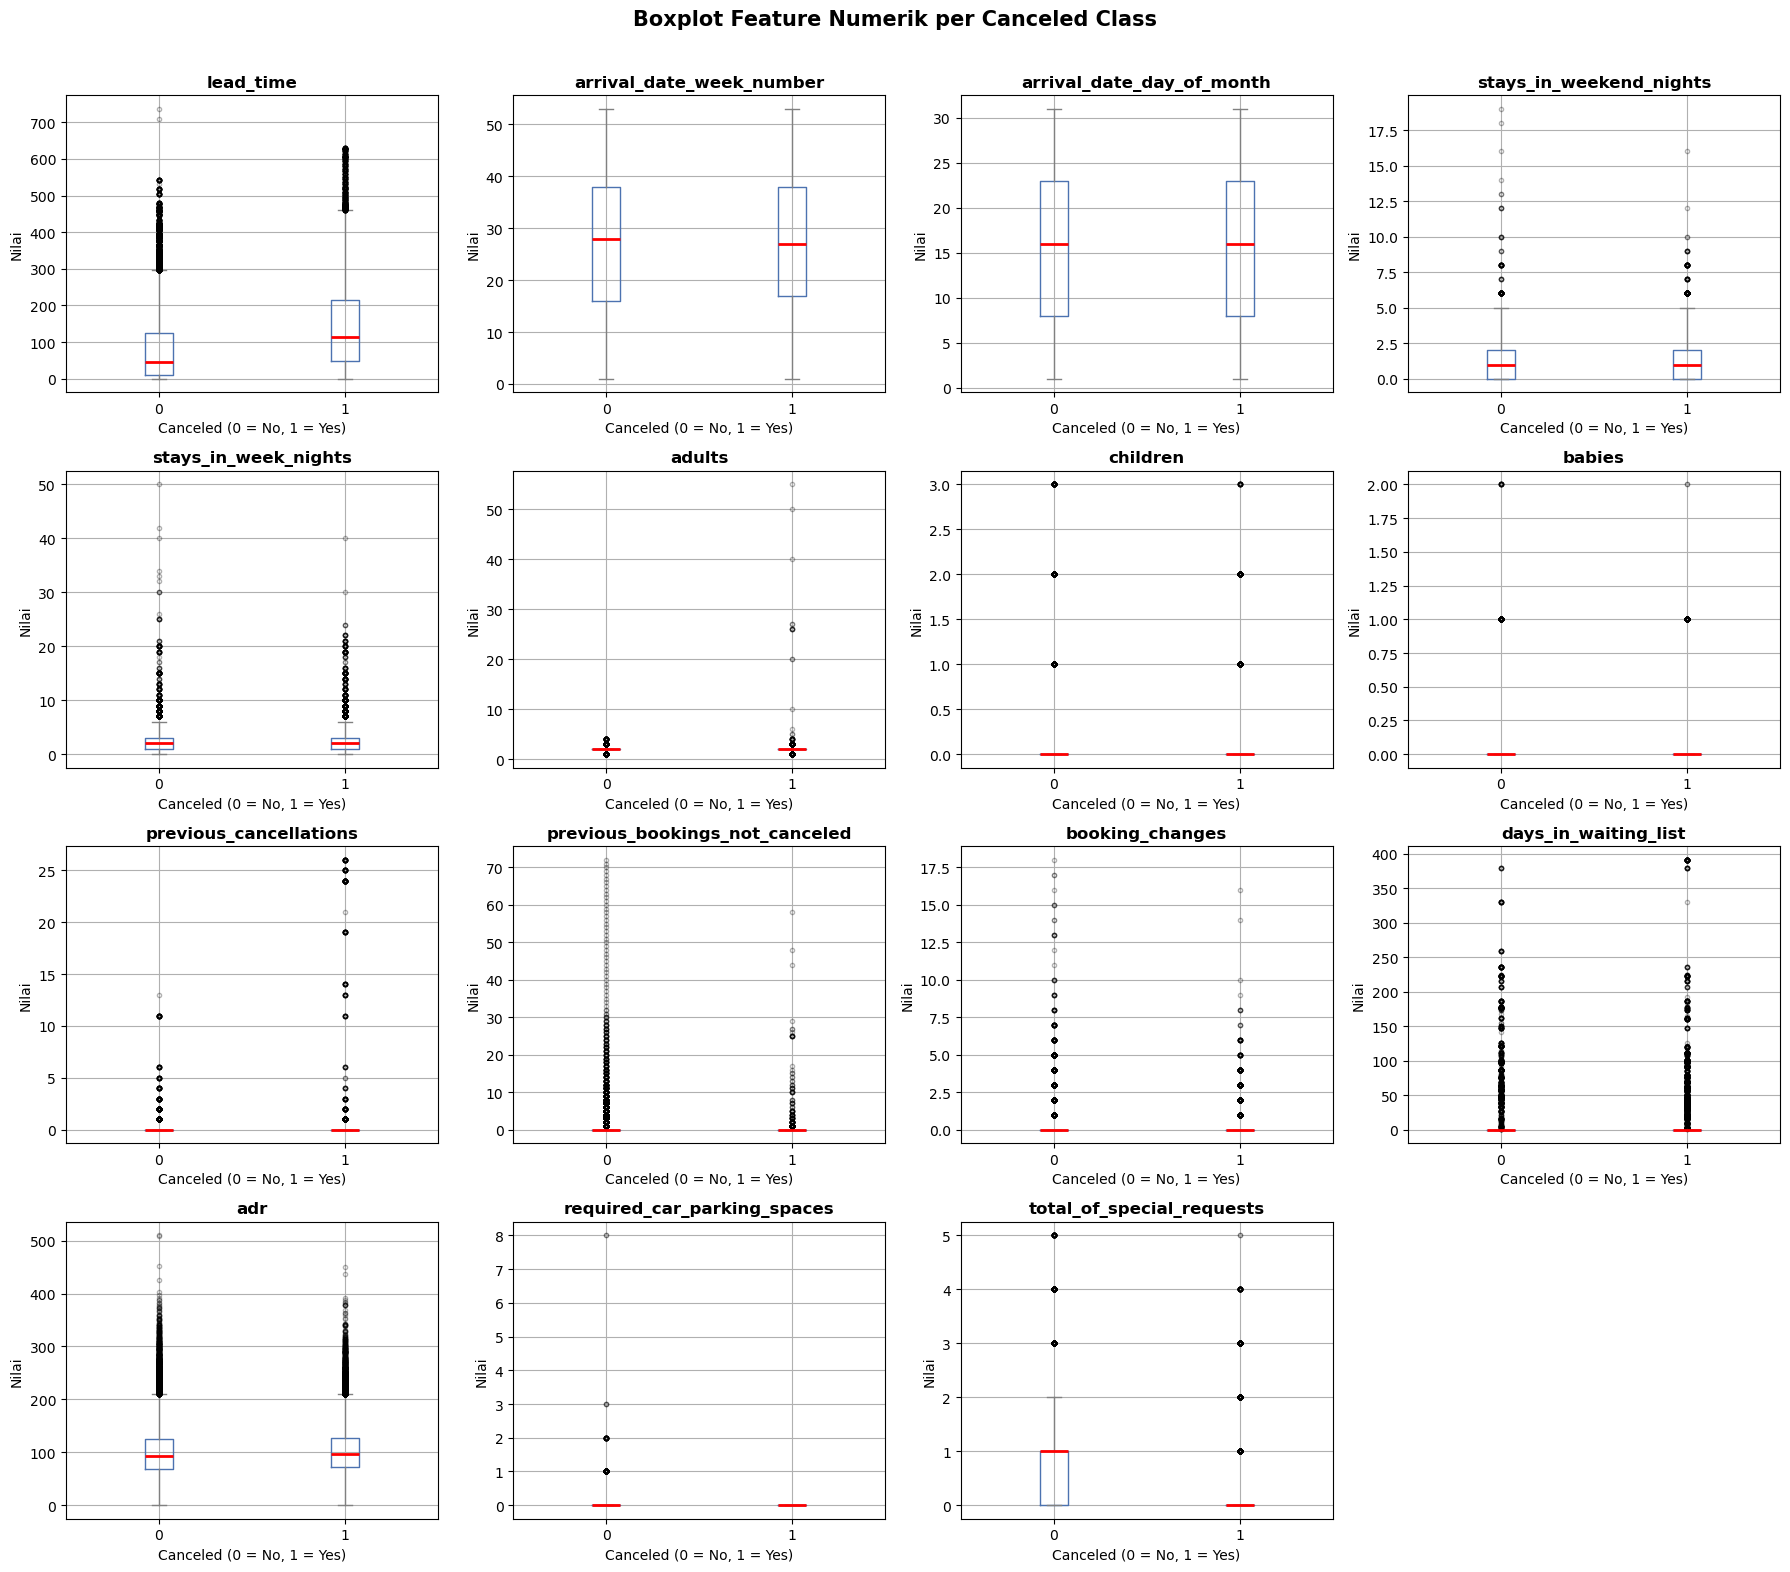

In [10]:
fig_ncols = 4
fig_nrows = math.ceil(len(num_cols) / fig_ncols)

fig, axes = plt.subplots(fig_nrows, fig_ncols, figsize=(18, 4 * fig_nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='is_canceled', ax=ax,
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=12, fontweight='bold') 
    ax.set_xlabel('Canceled (0 = No, 1 = Yes)')
    ax.set_ylabel('Nilai')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Feature Numerik per Canceled Class', fontsize=15, fontweight='bold')

if fig._suptitle:
    pass 

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Numerical Features vs Target - Mann-Whitney U Test

Berdasarkan histogram, boxplot, dan nilai skewness, sebagian besar fitur numerik tidak mengikuti distribusi normal. Beberapa fitur, seperti `lead_time`, `stay_in_week_nights`, `adr`, dan `days_in_waiting_list`, menunjukkan distribusi yang tidak simetris serta memiliki sejumlah nilai ekstrem. Sementara itu, fitur berbentuk count data, seperti `children`, `babies`, `previous_cancellations`, `previous_bookings_not_canceled`, dan `required_car_parking_spaces`, sangat terkonsentrasi pada nilai 0.

Oleh karena itu, digunakan **Mann–Whitney U test** sebagai metode non-parametrik untuk menguji perbedaan distribusi masing-masing fitur numerik antara kelompok **`Canceled`** dan **`Not Canceled`**.

Selain *p-value*, **rank-biserial correlation** digunakan sebagai ukuran *effect size* untuk mengukur besarnya perbedaan antar-kelompok. Dengan demikian, analisis tidak hanya menentukan apakah perbedaan tersebut **signifikan secara statistik**, tetapi juga mengevaluasi **seberapa besar perbedaannya secara praktis**.

In [11]:
def rank_biserial(u_stat, n1, n2):
    """Effect size untuk Mann-Whitney U. Range -1 s.d. 1, mirip interpretasi Cohen's d."""
    return 1 - (2 * u_stat) / (n1 * n2)

g0 = df[df['is_canceled'] == 0]
g1 = df[df['is_canceled'] == 1]

mwu_results = []
for col in num_cols:
    u_stat, p = stats.mannwhitneyu(g1[col], g0[col], alternative='two-sided')
    r = rank_biserial(u_stat, len(g1), len(g0))
    mwu_results.append([col, u_stat, p, r])

mwu_df = pd.DataFrame(mwu_results, columns=['feature', 'U_statistic', 'p_value', 'rank_biserial_r'])
mwu_df['abs_effect'] = mwu_df['rank_biserial_r'].abs()
mwu_df = mwu_df.sort_values('abs_effect', ascending=False).drop(columns='abs_effect').reset_index(drop=True)
mwu_df

,feature,U_statistic,p_value,rank_biserial_r
0,lead_time,2.284515e+09,0.000000e+00,-0.378236
1,total_of_special_requests,1.206834e+09,0.000000e+00,0.271923
2,booking_changes,1.430561e+09,0.000000e+00,0.136950
3,previous_cancellations,1.867899e+09,0.000000e+00,-0.126894
4,required_car_parking_spaces,1.493837e+09,0.000000e+00,0.098776
5,adr,1.756400e+09,1.762941e-66,-0.059627
6,adults,1.755732e+09,2.600563e-114,-0.059224
7,stays_in_week_nights,1.737694e+09,2.084653e-46,-0.048342
8,previous_bookings_not_canceled,1.589685e+09,0.000000e+00,0.040951
9,days_in_waiting_list,1.716094e+09,4.355540e-253,-0.035311


#### Mann–Whitney U Test Insight

- **Dengan 119.205 observasi, p-value perlu dibaca bersama effect size.** `arrival_date_week_number` (p=0,0075; r=-0,009) dan `arrival_date_day_of_month` (p=0,0389; r=0,007) signifikan secara statistik, tetapi effect size-nya mendekati nol sehingga perbedaannya tidak material secara praktis. `stays_in_weekend_nights` (p=0,1587) dan `children` (p=0,2924) tidak signifikan pada taraf 5%.

- **`lead_time` memiliki effect size terbesar (r=-0,378), diikuti `total_of_special_requests` (r=0,272).** Keduanya menunjukkan perbedaan distribusi antarkelas yang lebih besar dibandingkan fitur numerik lainnya.

- **`booking_changes` (r=0,137) dan `previous_cancellations` (r=-0,127) hanya menunjukkan efek kecil.** `required_car_parking_spaces` (r=0,099), `adr` (r=-0,060), dan fitur lainnya memiliki effect size kecil atau dapat diabaikan.

- **Secara keseluruhan, hanya `lead_time` yang mencapai effect size moderat.** Tidak ada satu fitur numerik yang memisahkan kelas dengan sangat kuat, sehingga cancellation lebih tepat diprediksi menggunakan kombinasi beberapa fitur. Tanda positif atau negatif mengikuti urutan kelompok pada perhitungan; arah bisnis sebaiknya dikonfirmasi menggunakan ringkasan nilai per kelas.


#### **1.2.2.1 Cancellation Rate Based on Lead Time**

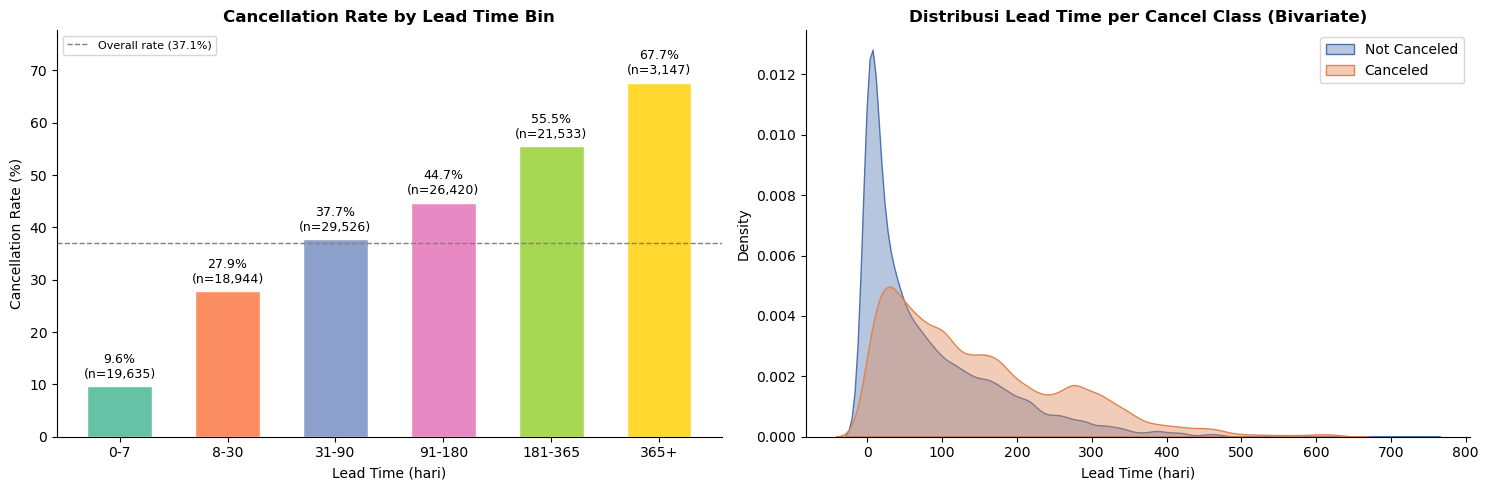

In [12]:
bins = [-1, 7, 30, 90, 180, 365, df['lead_time'].max()]
bin_labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=bins, labels=bin_labels)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

bin_stats = df.groupby('lead_time_bin', observed=True)['is_canceled'].agg(['mean', 'count'])
bin_stats['mean'] = bin_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

bars = ax[0].bar(bin_stats.index.astype(str), bin_stats['mean'],
                  color=sns.color_palette("Set2", len(bin_stats)), edgecolor='white', width=0.6)
for bar, (rate, n) in zip(bars, zip(bin_stats['mean'], bin_stats['count'])):
    ax[0].text(bar.get_x() + bar.get_width() / 2, rate + 1, f"{rate:.1f}%\n(n={n:,})",
               ha='center', va='bottom', fontsize=9)
ax[0].axhline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[0].set_title('Cancellation Rate by Lead Time Bin', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Lead Time (hari)')
ax[0].set_ylabel('Cancellation Rate (%)')
ax[0].set_ylim(0, bin_stats['mean'].max() + 10)
ax[0].legend(fontsize=8)
ax[0].spines[['top', 'right']].set_visible(False)

for cancel_val, label, color in zip([0, 1], ['Not Canceled', 'Canceled'], ['#4C72B0', '#DD8452']):
    subset = df.loc[df['is_canceled'] == cancel_val, 'lead_time']
    sns.kdeplot(subset, ax=ax[1], label=label, color=color, fill=True, alpha=0.4)
ax[1].set_title('Distribusi Lead Time per Cancel Class (Bivariate)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Lead Time (hari)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

##### Cancellation Rate by Lead Time Insight

- **Cancellation rate meningkat secara konsisten seiring bertambahnya lead time**, dari 9,6% pada 0–7 hari menjadi 27,9% pada 8–30 hari, 37,7% pada 31–90 hari, 44,7% pada 91–180 hari, 55,5% pada 181–365 hari, dan 67,7% pada 365+ hari.

- **Booking dengan lead time 365+ hari memiliki cancellation rate sekitar tujuh kali kelompok 0–7 hari.** Meskipun volumenya paling kecil, kategori ini masih mencakup 3.147 booking atau sekitar 2,6% data.

- **Kelompok 31–90 hari memiliki volume terbesar (29.526 booking)** dan cancellation rate 37,7%, sedikit di atas overall rate 37,1%. Kelompok 91–180 dan 181–365 hari juga material, masing-masing berisi 26.420 dan 21.533 booking dengan tingkat pembatalan yang semakin tinggi.

- **Panel KDE mendukung pola binning:** Not Canceled terkonsentrasi pada lead time rendah, sedangkan Canceled memiliki distribusi lebih lebar dan ekor lebih tebal pada lead time tinggi. Hasil ini konsisten dengan effect size `lead_time` sebesar |r|=0,378.

- **Business Implication:** booking di atas 180 hari layak memperoleh pemantauan risiko lebih intensif. Namun, lead time harus digabungkan dengan fitur lain dan tidak digunakan sebagai satu-satunya dasar intervensi.


### **1.2.2 Categorical Features VS Target**
#### **1.2.2.1 Low Cardinality Features**

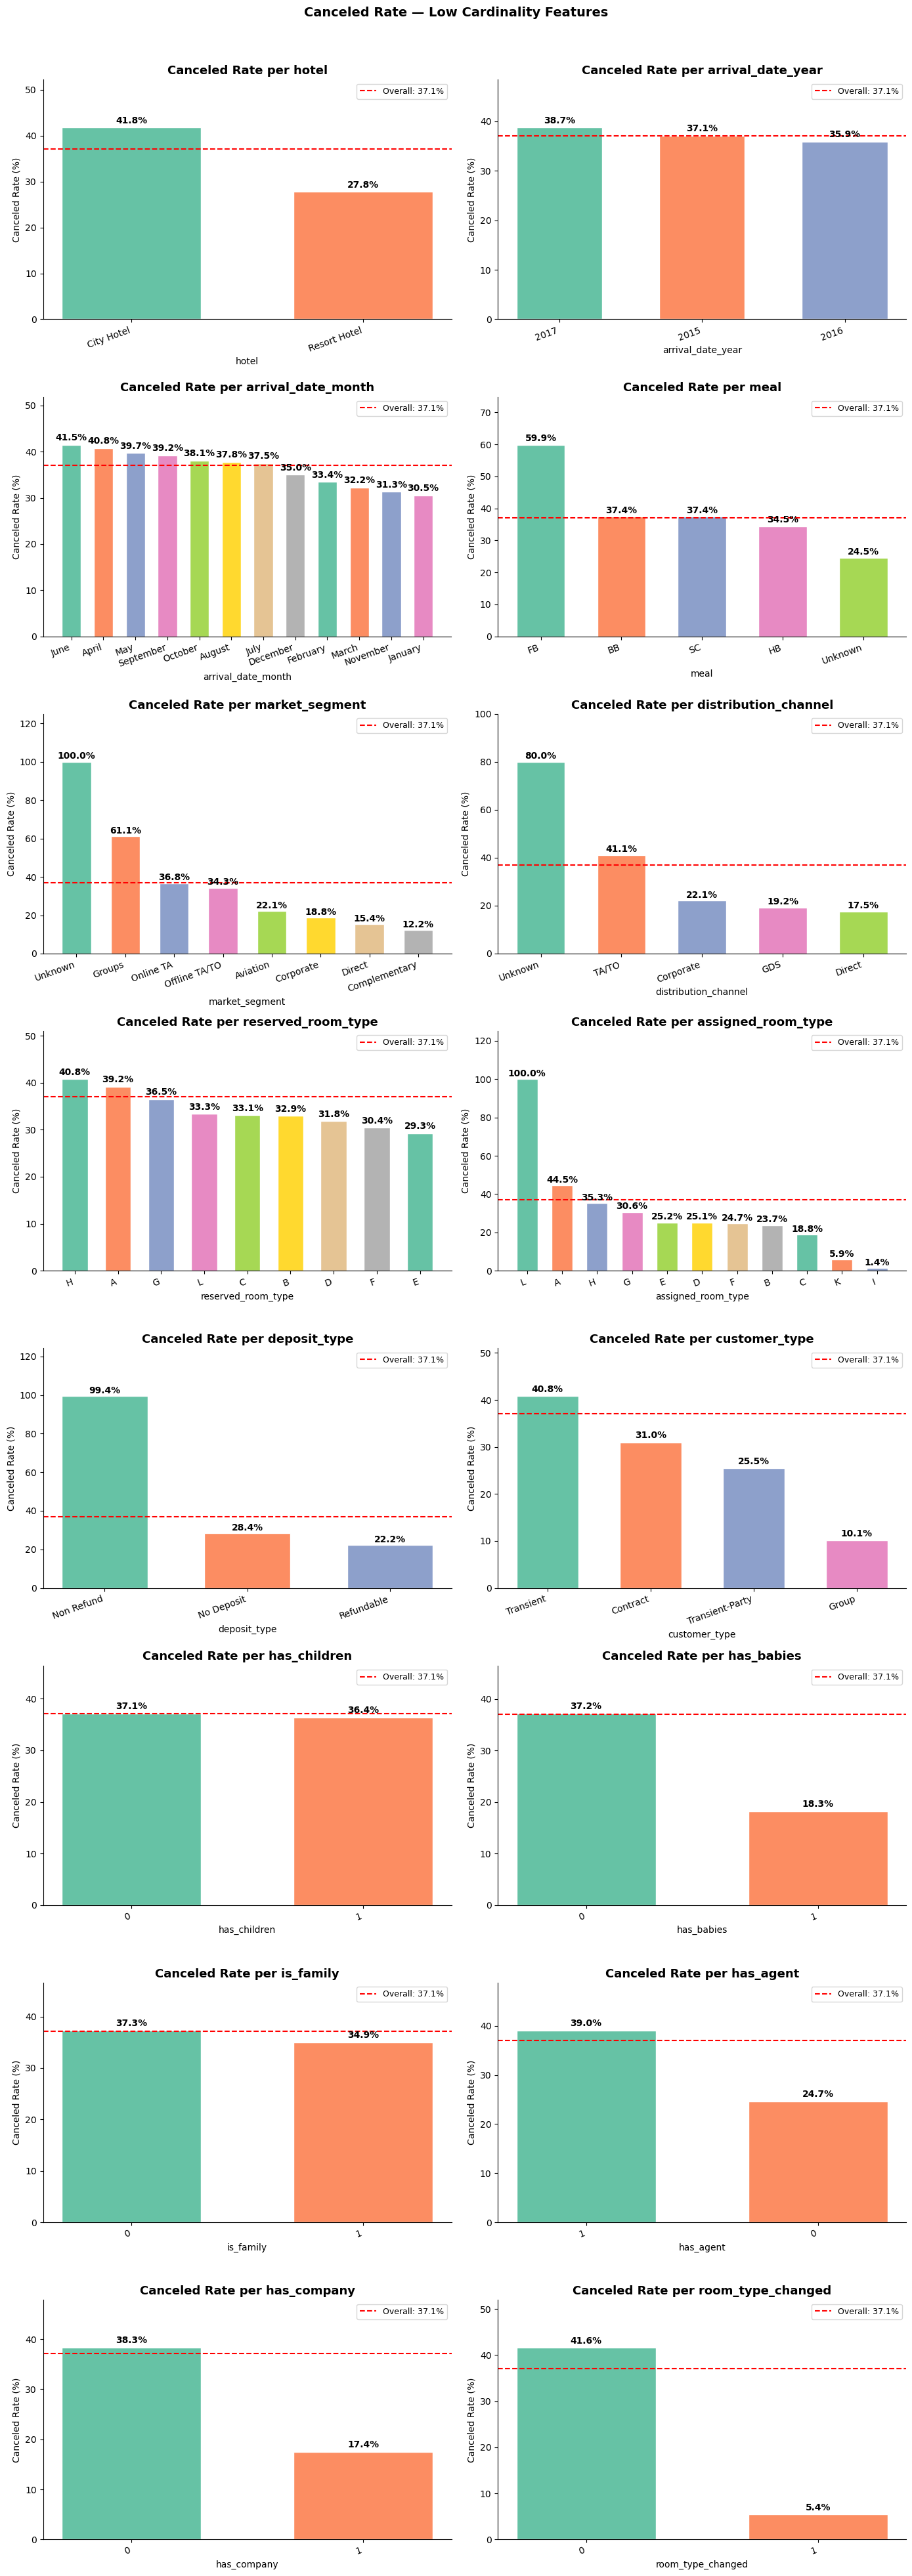

In [13]:
n_cols = 2
n_rows = math.ceil(len(low_card_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = np.atleast_1d(axes).flatten()

overall_rate = df["is_canceled"].mean() * 100

for ax, col in zip(axes, low_card_cols):

    canceled_rate = (
        df.groupby(col)["is_canceled"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    bars = ax.bar(
        canceled_rate.index.astype(str),
        canceled_rate.values,
        color=sns.color_palette("Set2", len(canceled_rate)),
        edgecolor="white",
        width=0.6
    )

    for bar, v in zip(bars, canceled_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.5,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.axhline(
        overall_rate,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Overall: {overall_rate:.1f}%"
    )

    ax.set_title(
        f"Canceled Rate per {col}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Canceled Rate (%)")
    ax.set_ylim(0, canceled_rate.max() * 1.25)

    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.setp(
        ax.get_xticklabels(),
        rotation=20,
        ha="right"
    )

for j in range(len(low_card_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Canceled Rate — Low Cardinality Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

##### Canceled Rate — Low Cardinality Features Insight

- **`deposit_type` menunjukkan perbedaan paling tajam:** Non Refund memiliki cancellation rate 99,4%, jauh di atas No Deposit (28,4%) dan Refundable (22,2%). Karena hasil ini kontraintuitif, pola tersebut perlu dianalisis bersama market segment, agent, dan timing ketersediaan fitur sebelum ditafsirkan secara kausal.

- **Groups merupakan market segment berisiko tinggi yang material**, dengan cancellation rate 61,1%. Online TA (36,8%) dan Offline TA/TO (34,3%) berada dekat atau di bawah overall rate 37,1%, sedangkan Direct jauh lebih rendah (15,4%).

- **TA/TO merupakan distribution channel utama dengan rate di atas rata-rata**, yaitu 41,1%. Corporate, GDS, dan Direct lebih rendah, masing-masing 22,1%, 19,2%, dan 17,5%. Unknown mencapai 80%, tetapi hanya terdiri dari lima observasi.

- **City Hotel memiliki cancellation rate lebih tinggi daripada Resort Hotel** (41,8% vs 27,8%). Transient juga merupakan customer type dengan rate tertinggi (40,8%), sedangkan Group paling rendah (10,1%).

- **`has_children` hampir tidak membedakan kedua kelas** (37,1% tanpa anak vs 36,4% dengan anak). Perbedaan lebih besar terlihat pada `has_agent` (39,0% vs 24,7%), `has_company` (17,4% vs 38,3%), dan `room_type_changed` (5,4% vs 41,6%).

- **Kategori ekstrem perlu dibaca bersama sample size.** Market segment Unknown dan assigned room type V/L mencapai 100%, tetapi kategori langka tidak boleh disamakan dengan pola dari kategori berukuran besar.

- **Modeling Implication:** prioritaskan validasi `deposit_type`, `market_segment`, `distribution_channel`, `hotel`, dan `customer_type`. Evaluasi leakage pada `assigned_room_type` dan `room_type_changed`, serta tampilkan count per kategori sebelum menarik kesimpulan dari rate ekstrem.


##### Low Cardinality Features vs Target — Chi-Square Test + Cramér's V

Untuk fitur kategorikal dengan **low cardinality**, digunakan **Chi-square test of independence** untuk menguji keberadaan asosiasi antara masing-masing fitur kategorikal dan `is_canceled`.

Selanjutnya, **Cramér's V** digunakan sebagai ukuran *effect size* untuk mengukur kekuatan asosiasi tersebut. Nilai Cramér's V berada pada rentang **0–1**, dengan nilai 0 menunjukkan tidak adanya asosiasi dan nilai 1 menunjukkan asosiasi sempurna.

Penggunaan Cramér's V melengkapi *chi-square test* dengan memberikan ukuran kekuatan asosiasi yang lebih terstandarisasi, sehingga interpretasi hasil tidak hanya bergantung pada *chi-square statistic* dan ukuran tabel kontingensi.

In [14]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

chi2_results = []
for col in low_card_cols:
    ct = pd.crosstab(df[col], df['is_canceled'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    # flag kalau ada expected cell count < 5 (asumsi chi-square dilanggar)
    min_expected = expected.min()
    chi2_results.append([col, chi2, p, v, min_expected])

chi2_df = pd.DataFrame(
    chi2_results,
    columns=['feature', 'chi2_statistic', 'p_value', 'cramers_v', 'min_expected_count']
).sort_values('cramers_v', ascending=False).reset_index(drop=True)
chi2_df

,feature,chi2_statistic,p_value,cramers_v,min_expected_count
0,deposit_type,27639.507537,0.000000e+00,0.481524,60.063873
1,market_segment,8499.623600,0.000000e+00,0.267025,0.741529
2,room_type_changed,7256.201283,0.000000e+00,0.246722,5485.092219
3,assigned_room_type,4843.159149,0.000000e+00,0.201566,0.370765
4,distribution_channel,3740.674972,0.000000e+00,0.177145,1.853823
5,hotel,2239.892940,0.000000e+00,0.137078,14847.270375
6,customer_type,2224.624237,0.000000e+00,0.136610,212.818909
7,has_agent,1244.933968,1.047231e-272,0.102194,6036.048488
8,has_company,1183.863848,1.959543e-259,0.099656,2509.335145
9,reserved_room_type,631.418540,4.102515e-131,0.072780,2.224588


##### Chi-Square Test Insight

- **`deposit_type` memiliki asosiasi terkuat dengan cancellation (Cramér's V=0,482)**, diikuti `market_segment` (0,267), `room_type_changed` (0,247), `assigned_room_type` (0,202), dan `distribution_channel` (0,177).

- **Signifikansi statistik tidak selalu berarti asosiasi yang material.** `arrival_date_year` (V=0,026), `is_family` (V=0,013), dan `has_babies` (V=0,034) memiliki asosiasi sangat lemah meskipun p-value-nya kecil.

- **`has_children` tidak menunjukkan asosiasi signifikan** (p=0,171; V=0,004), konsisten dengan cancellation rate kedua kategorinya yang hampir sama.

- **Asumsi Chi-Square perlu diperhatikan** pada `market_segment`, `assigned_room_type`, `distribution_channel`, dan `reserved_room_type` karena minimum expected count berada di bawah 5. Kategori langka dapat digabungkan secara masuk akal sebelum pengujian ulang.

- **Modeling Implication:** Cramér's V mengukur asosiasi, bukan kausalitas maupun feature importance model. `assigned_room_type` dan `room_type_changed` tetap perlu diperiksa dari sisi availability time untuk mencegah leakage.


##### **1.2.2.1.1 Cancellation Rate by Hotel**

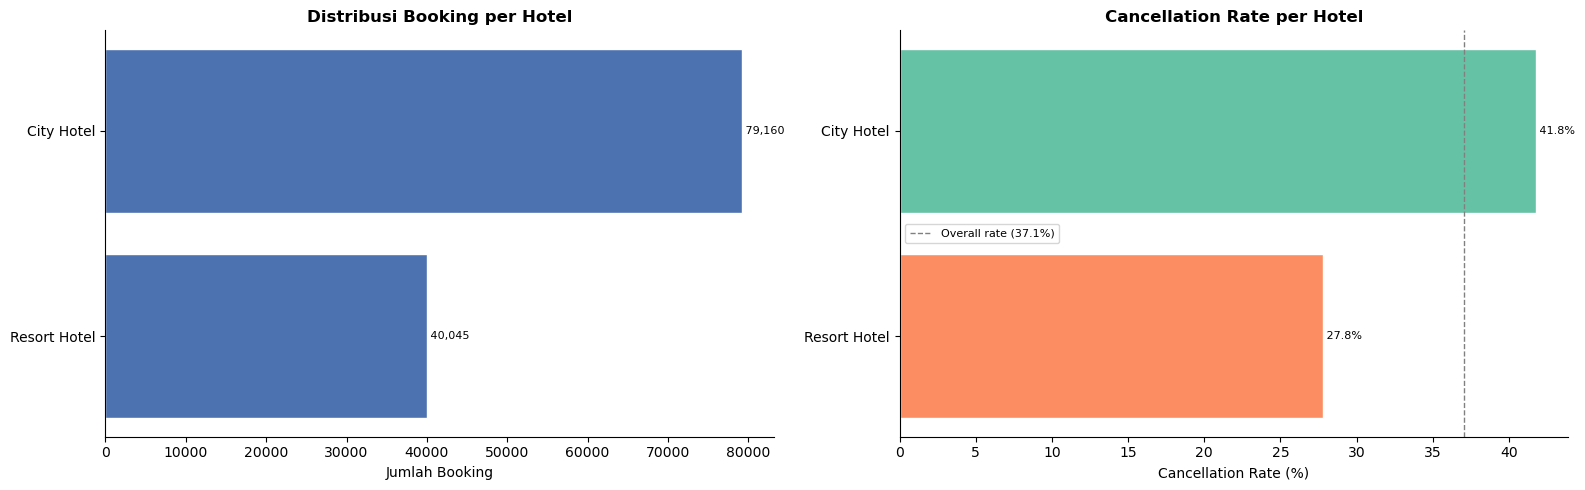

In [15]:
seg_stats = df.groupby('hotel', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Hotel', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Hotel', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Hotel Type Insight

- **City Hotel mendominasi volume booking dengan 79.160 reservasi** dan memiliki cancellation rate 41,8%, lebih tinggi dari overall rate 37,1%.

- **Resort Hotel mencakup 40.045 booking dengan cancellation rate 27,8%**, yaitu 14 percentage points lebih rendah daripada City Hotel.

- **Business Implication:** City Hotel menjadi area prioritas karena menggabungkan volume terbesar dan tingkat pembatalan tertinggi. Namun, analisis lanjutan diperlukan untuk menentukan apakah perbedaannya berasal dari market segment, channel, seasonality, atau karakteristik booking lainnya.


##### **1.2.2.1.2 Cancellation Rate by Year**

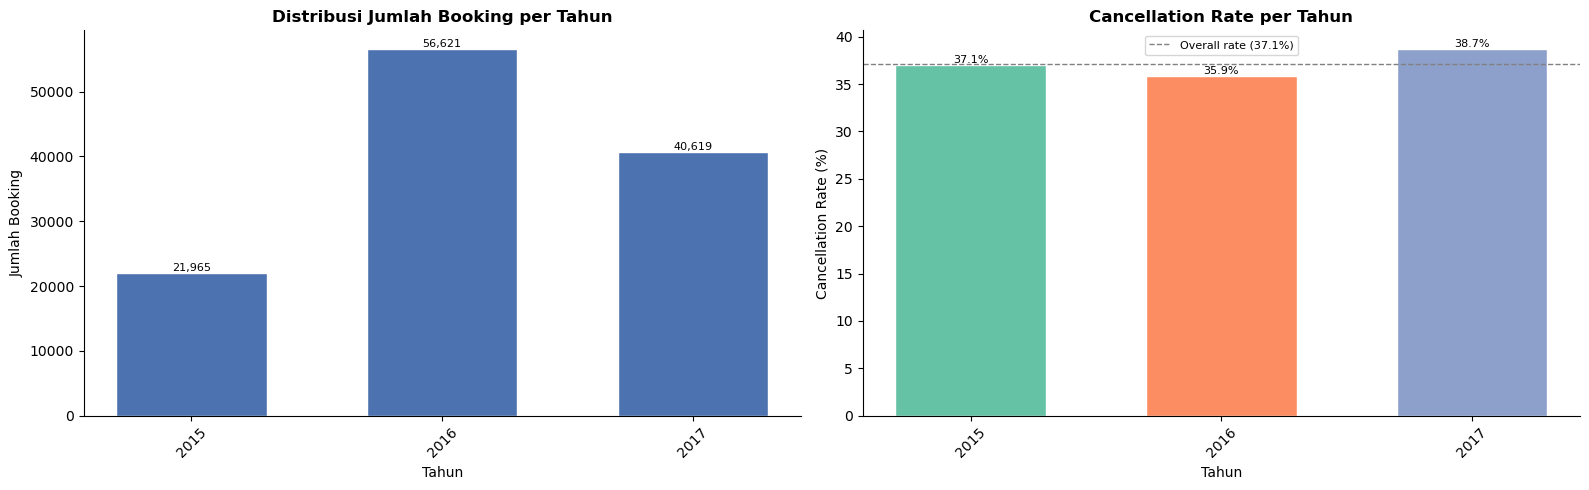

In [16]:
year_order = [2015, 2016, 2017]

year_stats = (df.groupby('arrival_date_year', observed=True)['is_canceled'].agg(['count', 'mean']).reindex(year_order)
)
year_stats['mean'] = year_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100
year_stats.index = year_stats.index.astype(str)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].bar(year_stats.index, year_stats['count'], color='#4C72B0', edgecolor='white', width=0.6)
for bar, v in zip(bars0, year_stats['count']):
    ax[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha='center', va='bottom', fontsize=8)
ax[0].set_title('Distribusi Jumlah Booking per Tahun', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Tahun')
ax[0].set_ylabel('Jumlah Booking')
ax[0].tick_params(axis='x', rotation=45)
ax[0].spines[['top', 'right']].set_visible(False)

bars1 = ax[1].bar(year_stats.index, year_stats['mean'], 
                   color=sns.color_palette("Set2", len(year_stats)), edgecolor='white', width=0.6)
for bar, v in zip(bars1, year_stats['mean']):
    ax[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=8)
ax[1].axhline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Tahun', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Tahun')
ax[1].set_ylabel('Cancellation Rate (%)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Year Insight

- **Tahun 2016 memiliki volume terbesar**, yaitu 56.621 booking, tetapi cancellation rate terendah sebesar 35,9%.

- **Tahun 2017 memiliki cancellation rate tertinggi sebesar 38,7%** dari 40.619 booking. Tahun 2015 mencatat 37,1% dari 21.965 booking.

- **Tidak terdapat tren kenaikan yang konsisten:** rate turun dari 37,1% pada 2015 menjadi 35,9% pada 2016, lalu naik menjadi 38,7% pada 2017. Selisih antartahun juga relatif kecil, sehingga belum cukup untuk menyimpulkan temporal drift hanya dari chart ini.

- **Catatan:** interpretasi antartahun perlu mempertimbangkan bahwa 2015 dan 2017 tidak selalu mencakup satu tahun kalender penuh.


##### **1.2.2.1.3 Cancellation Rate by Month**

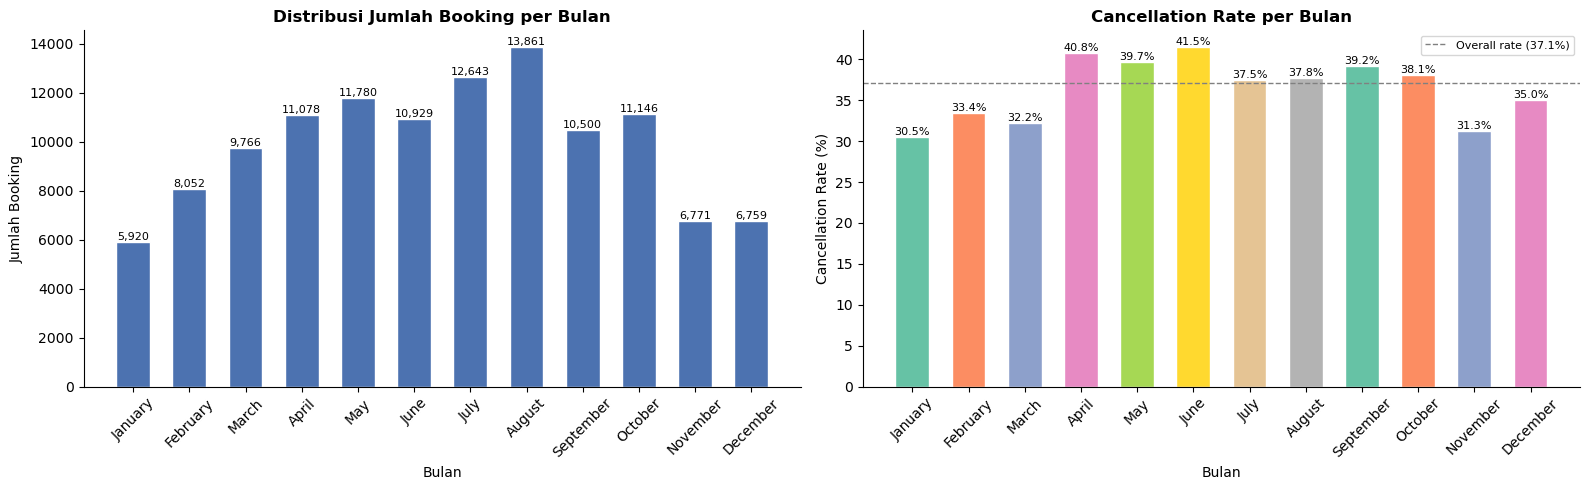

In [17]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_stats = df.groupby('arrival_date_month', observed=True)['is_canceled'].agg(['count', 'mean']).reindex(month_order)
month_stats['mean'] = month_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].bar(month_stats.index, month_stats['count'], color='#4C72B0', edgecolor='white', width=0.6)
for bar, v in zip(bars0, month_stats['count']):
    ax[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha='center', va='bottom', fontsize=8)
ax[0].set_title('Distribusi Jumlah Booking per Bulan', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Bulan')
ax[0].set_ylabel('Jumlah Booking')
ax[0].tick_params(axis='x', rotation=45)
ax[0].spines[['top', 'right']].set_visible(False)

bars1 = ax[1].bar(month_stats.index, month_stats['mean'],
                   color=sns.color_palette("Set2", len(month_stats)), edgecolor='white', width=0.6)
for bar, v in zip(bars1, month_stats['mean']):
    ax[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=8)
ax[1].axhline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Bulan', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Bulan')
ax[1].set_ylabel('Cancellation Rate (%)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Month Insight

- **Agustus dan Juli memiliki volume booking tertinggi**, masing-masing sebanyak 13.861 dan 12.643 booking. Cancellation rate keduanya sebesar 37,8% dan 37,5%, hanya sedikit di atas overall rate 37,1%.

- **Cancellation rate tertinggi justru terjadi pada Juni (41,5%)**, diikuti April (40,8%) dan Mei (39,7%). Ini menunjukkan bahwa puncak volume booking tidak selalu sama dengan puncak cancellation rate.

- **Seluruh bulan April–Oktober berada di atas overall rate**, dengan rentang 37,5%–41,5%. Sebaliknya, November–Maret berada di bawah rata-rata, dengan rentang 30,5%–35,0%, sehingga terdapat indikasi pola musiman.

- **Januari memiliki volume dan cancellation rate terendah**, yaitu 5.920 booking dan 30,5%. Prioritas operasional sebaiknya mempertimbangkan volume dan rate secara bersamaan, bukan hanya salah satunya.


##### **1.2.2.1.4 Cancellation Rate by Meal**

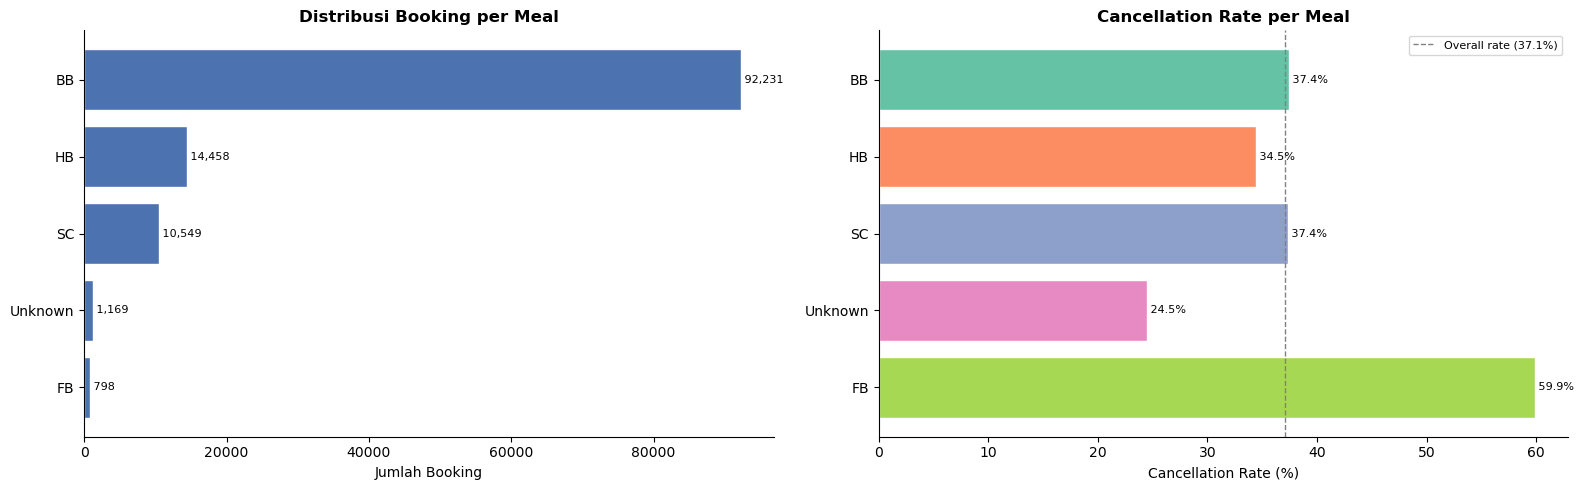

In [18]:
seg_stats = df.groupby('meal', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Meal', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Meal', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Meal Insight

- **BB mendominasi volume dengan 92.231 booking**, dengan cancellation rate 37,4%, hampir sama dengan overall rate 37,1%. SC juga memiliki rate 37,4% dari 10.549 booking.
- **FB memiliki rate tertinggi sebesar 59,9%, tetapi hanya terdiri dari 798 booking.** HB memiliki 14.458 booking dengan rate 34,5%, sedangkan Unknown mencatat 24,5% dari 1.169 booking.
- **Kesimpulan:** meal bukan pembeda kuat untuk kategori besar BB dan SC. Rate FB yang tinggi perlu dibaca dengan ukuran sampelnya dan tidak boleh langsung ditafsirkan secara kausal.


##### **1.2.2.1.5 Cancellation Rate by Market Segment**

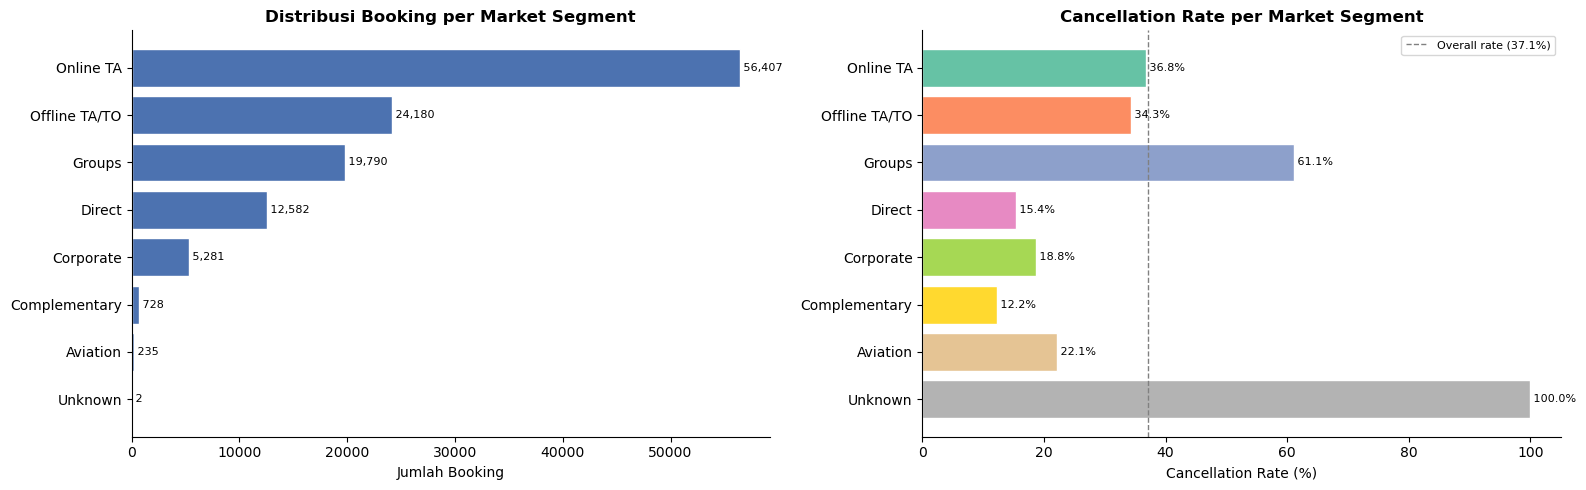

In [19]:
seg_stats = df.groupby('market_segment', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Market Segment', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Market Segment', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Market Segment Insight

- **Online TA mendominasi volume dengan 56.407 booking (47,3%)**, tetapi cancellation rate-nya 36,8%, sedikit di bawah overall rate 37,1%. Volume yang besar tetap menjadikannya kontributor besar terhadap jumlah cancellation.

- **Groups merupakan segmen dengan risiko tertinggi yang material.** Dari 19.790 booking, 61,1% dibatalkan—sekitar 24 percentage points di atas overall rate.

- **Offline TA/TO mencakup 24.180 booking dengan rate 34,3%**, sedangkan Direct memiliki 12.582 booking dengan rate hanya 15,4%. Corporate, Aviation, dan Complementary juga berada di bawah rata-rata, masing-masing 18,8%, 22,1%, dan 12,2%.

- **Unknown mencapai 100%, tetapi hanya terdiri dari dua booking**, sehingga tidak representatif.

- **Business Implication:** prioritaskan mitigasi risiko pada Groups dan pengelolaan volume pada Online TA. Perbedaan antarkategori menunjukkan asosiasi, bukan bukti bahwa market segment menyebabkan cancellation.


##### **1.2.2.1.6 Cancellation Rate by Distribution Channel**

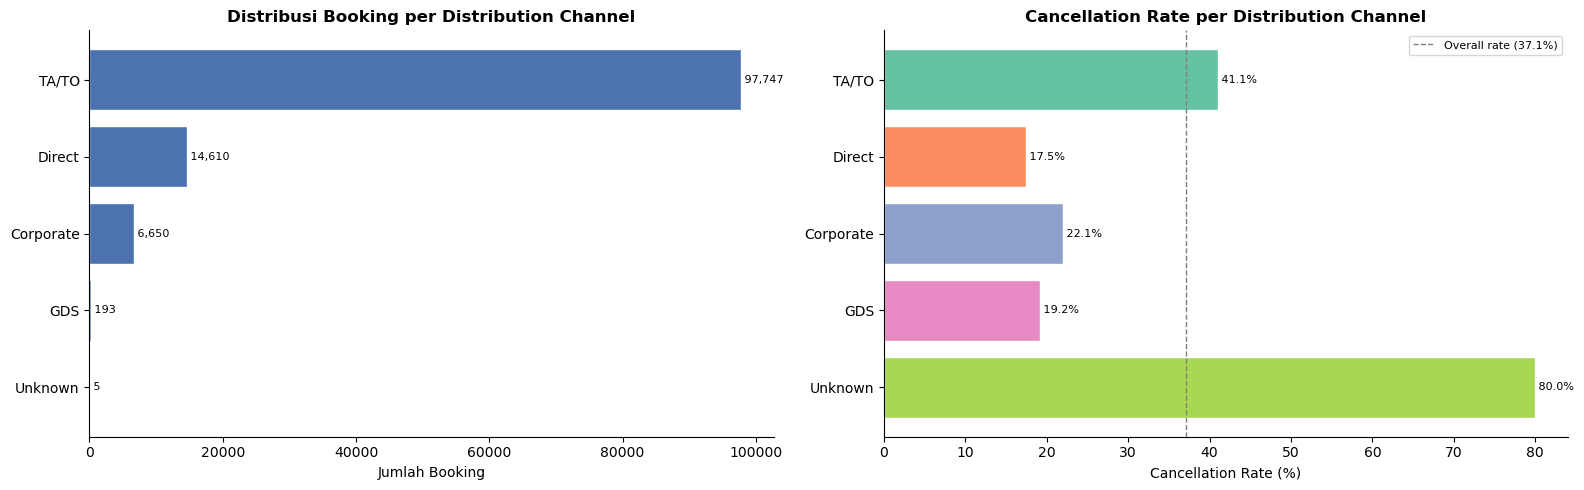

In [20]:
seg_stats = df.groupby('distribution_channel', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Distribution Channel', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Distribution Channel', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Distribution Channel Insight

- **TA/TO mendominasi dengan 97.747 booking atau 82,0% dari seluruh reservasi.** Cancellation rate-nya sebesar 41,1%, lebih tinggi daripada overall rate 37,1%, sehingga channel ini menjadi kontributor utama jumlah pembatalan.

- **Direct merupakan channel terbesar kedua dengan 14.610 booking**, tetapi cancellation rate-nya hanya 17,5%. Corporate mencakup 6.650 booking dengan rate 22,1%.

- **GDS memiliki rate 19,2%, tetapi hanya mencakup 193 booking.** Unknown mencapai 80%, tetapi hanya terdiri dari lima booking; keduanya perlu dibaca dengan hati-hati.

- **Business Implication:** TA/TO menjadi fokus utama karena menggabungkan volume dominan dan rate di atas rata-rata. Analisis berikutnya perlu memecah TA/TO berdasarkan market segment, agent, deposit type, dan lead time sebelum menentukan intervensi.


##### **1.2.2.1.7 Cancellation Rate by Reserved Room Type**

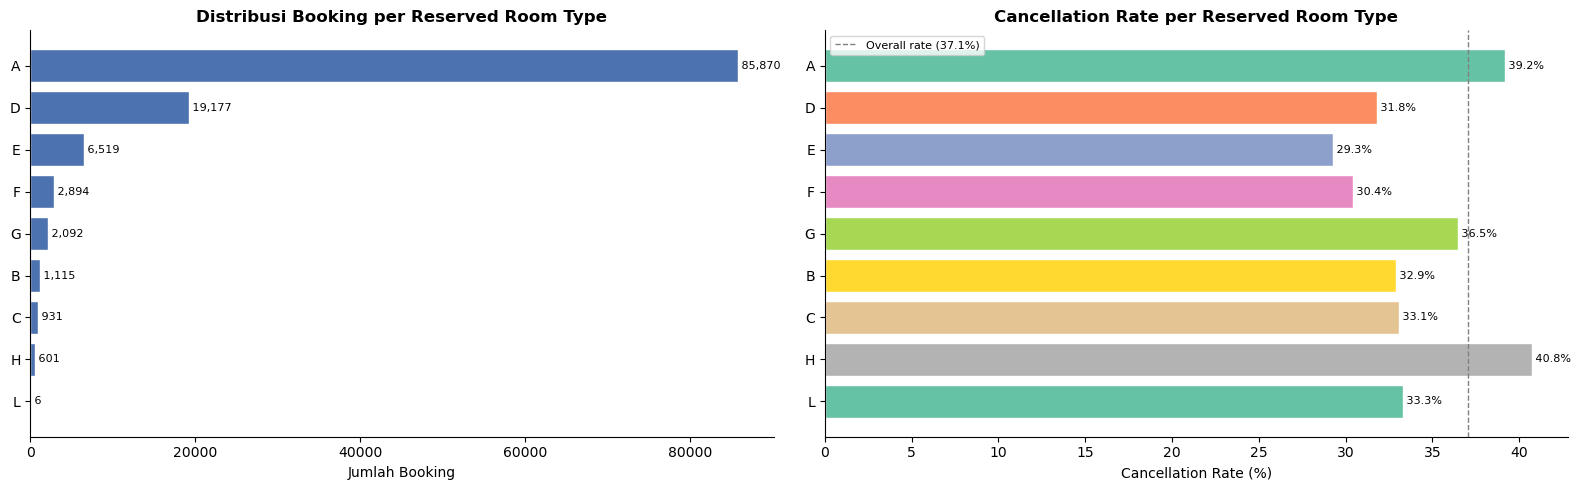

In [21]:
seg_stats = df.groupby('reserved_room_type', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Reserved Room Type', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Reserved Room Type', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Reserved Room Type Insight

- **Room type A mendominasi volume dengan 85.870 booking** dan memiliki cancellation rate 39,2%, sedikit di atas overall rate 37,1%.
- **Rentang rate pada kategori berukuran material relatif terbatas**, dari 29,3% pada E sampai 40,8% pada H. Tipe L memiliki rate 33,3%, tetapi hanya terdiri dari enam booking.
- **Kesimpulan:** reserved room type menunjukkan variasi cancellation yang moderat, tetapi tidak ada pemisahan ekstrem pada kategori berukuran besar.


##### **1.2.2.1.8 Cancellation Rate by Assigned Room Type**

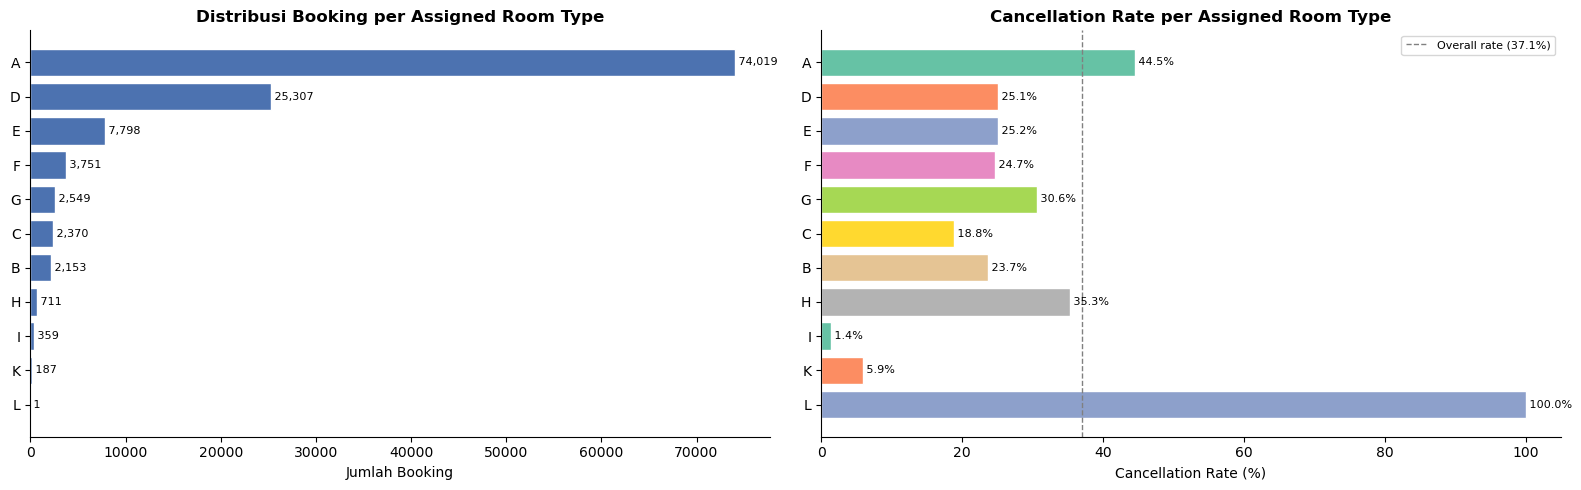

In [22]:
seg_stats = df.groupby('assigned_room_type', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Assigned Room Type', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Assigned Room Type', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Assigned Room Type Insight

- **Assigned room type A memiliki volume terbesar (74.019 booking) dan rate 44,5%**, di atas overall rate 37,1%.
- **Tipe I dan K memiliki rate sangat rendah**, masing-masing 1,4% dan 5,9%, sedangkan tipe V dan L mencapai 100%. Nilai ekstrem perlu dibaca bersama sample size; tipe L hanya memiliki satu booking.
- **Modeling Implication:** variasi yang sangat tajam dapat terlihat prediktif, tetapi assigned room type berpotensi baru tersedia setelah booking dibuat. Exclude fitur ini apabila model digunakan pada saat booking untuk mencegah leakage.


##### **1.2.2.1.9 Cancellation Rate by Deposit Type**

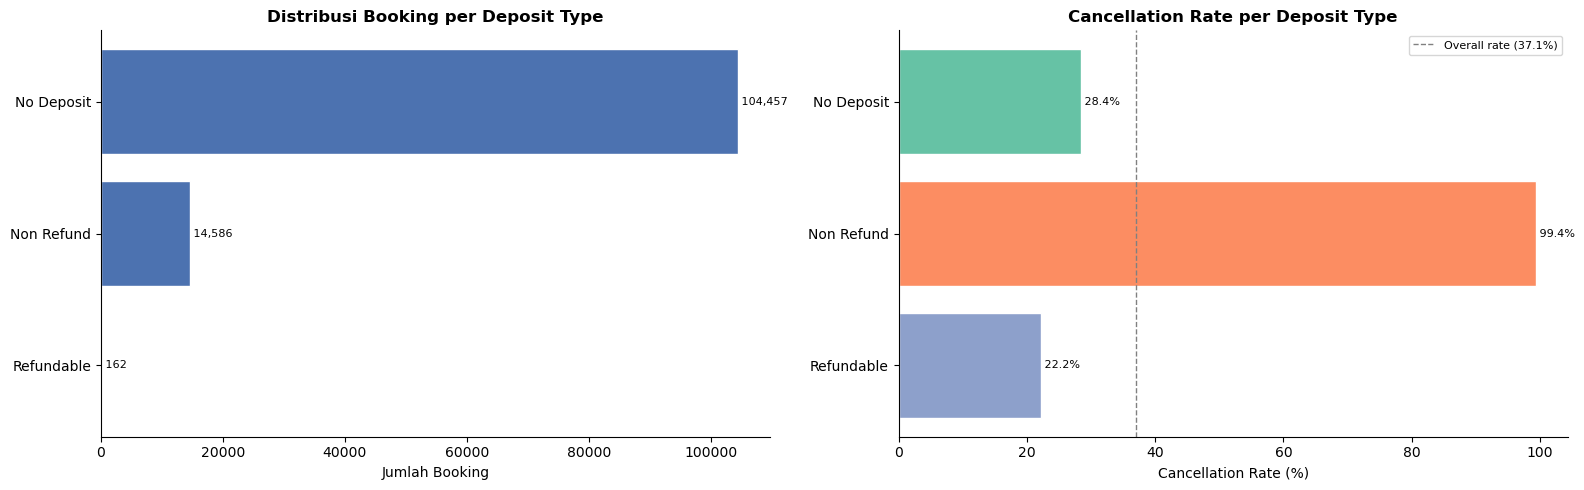

In [23]:
seg_stats = df.groupby('deposit_type', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Deposit Type', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Deposit Type', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Deposit Type Insight

- **No Deposit mendominasi volume dengan 104.457 booking (87,6%)**, dengan cancellation rate 28,4%.
- **Non Refund mencakup 14.586 booking (12,2%) dan memiliki cancellation rate ekstrem sebesar 99,4%.** Refundable hanya terdiri dari 162 booking dengan rate 22,2%.
- **Kesimpulan:** Non Refund merupakan pola paling tajam, tetapi hasilnya kontraintuitif dan perlu diperiksa bersama country, agent, serta market segment sebelum diterjemahkan menjadi kebijakan bisnis.


##### **1.2.2.1.10 Cancellation Rate by Customer Type**

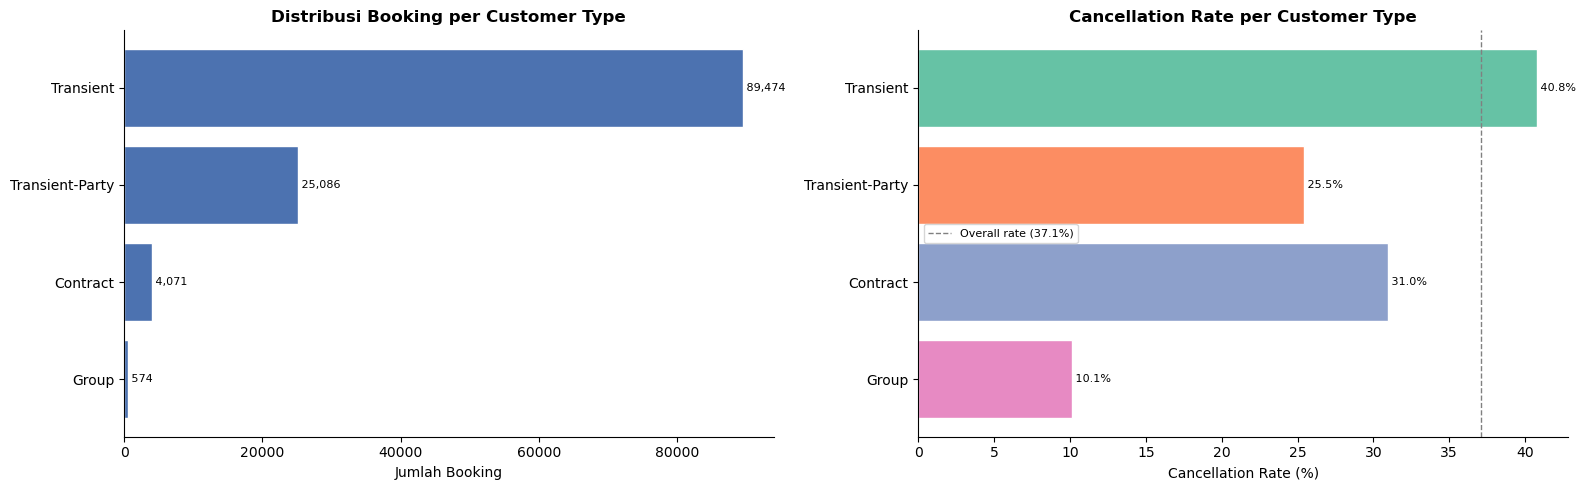

In [24]:
seg_stats = df.groupby('customer_type', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Customer Type', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Customer Type', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Cancellation Rate by Customer Type Insight

- **Transient mendominasi volume dengan 89.474 booking (75,1%)** dan memiliki cancellation rate tertinggi sebesar 40,8%.
- **Transient-Party mencakup 25.086 booking dengan rate 25,5%**, sedangkan Contract mencatat 31,0% dari 4.071 booking dan Group hanya 10,1% dari 574 booking.
- **Kesimpulan:** Transient menjadi kategori paling material karena menggabungkan volume terbesar dan rate di atas overall 37,1%.


##### **1.2.2.1.11 Cancellation Rate by Has Children or Not**

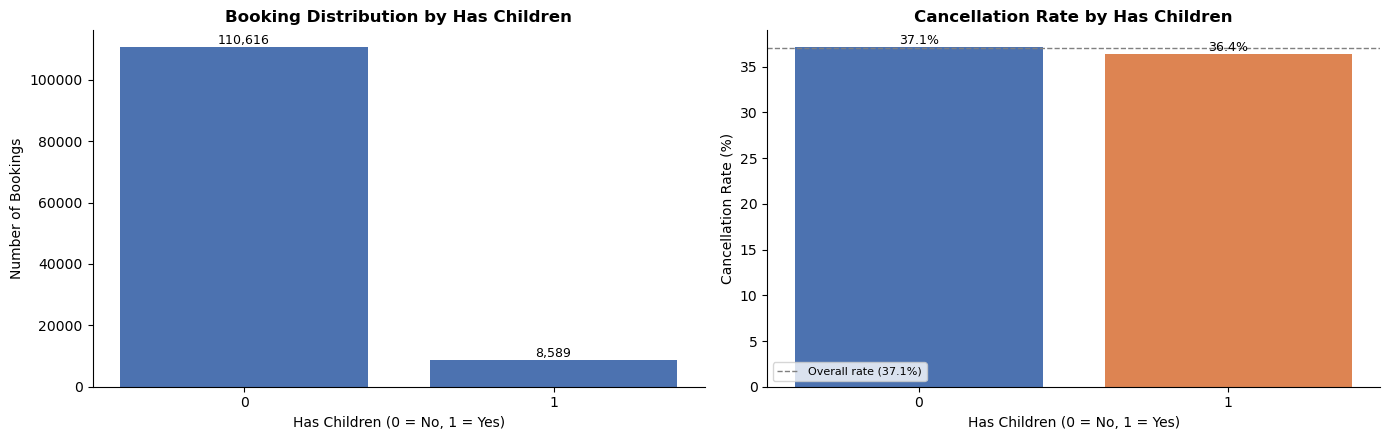

,has_children,booking_count,cancellation_rate
0,0,110616,37.13
1,1,8589,36.38


In [25]:
feature = "has_children"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Has Children", fontweight="bold")
ax[0].set_xlabel("Has Children (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Has Children", fontweight="bold")
ax[1].set_xlabel("Has Children (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Has Children Insight

- **Sebanyak 110.616 booking (92,8%) tidak memiliki anak**, sedangkan 8.589 booking (7,2%) memiliki anak.
- Cancellation rate kedua kelompok hampir sama: **37,1% tanpa anak dan 36,4% dengan anak**.
- **Kesimpulan:** `has_children` hampir tidak memberikan pemisahan cancellation secara individual, konsisten dengan hasil Chi-Square yang tidak signifikan (p=0,171; V=0,004).


##### **1.2.2.1.12 Cancellation Rate by Has Babies or Not**

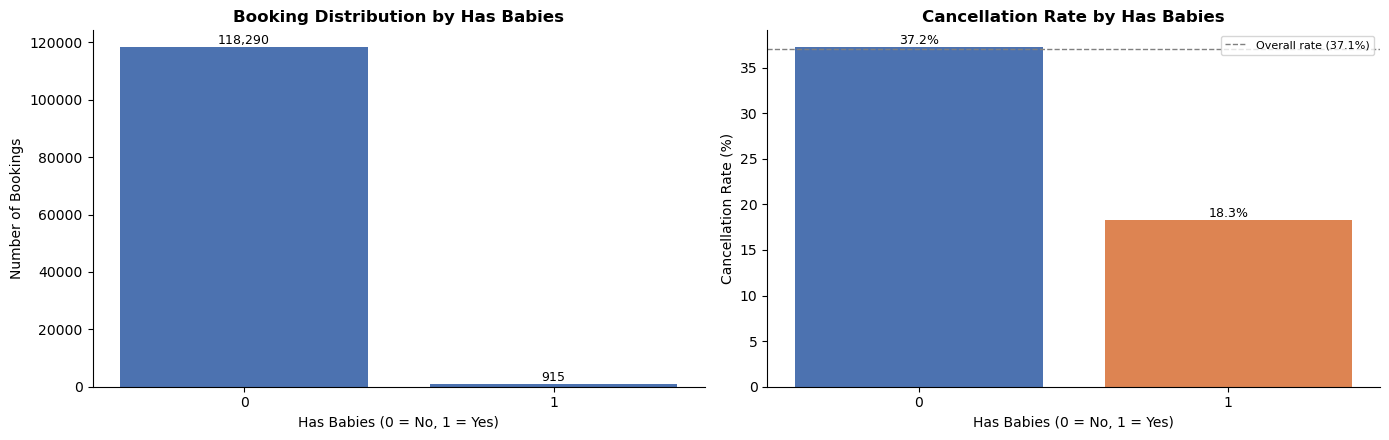

,has_babies,booking_count,cancellation_rate
0,0,118290,37.22
1,1,915,18.25


In [26]:
feature = "has_babies"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Has Babies", fontweight="bold")
ax[0].set_xlabel("Has Babies (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Has Babies", fontweight="bold")
ax[1].set_xlabel("Has Babies (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Has Babies Insight

- **Sebanyak 118.290 booking (99,2%) tidak memiliki bayi**, sedangkan hanya 915 booking (0,8%) yang memiliki bayi.
- Cancellation rate booking dengan bayi sebesar **18,3%**, jauh lebih rendah daripada booking tanpa bayi sebesar **37,2%**.
- **Kesimpulan:** terdapat perbedaan arah yang jelas, tetapi kategori dengan bayi sangat kecil sehingga kekuatan praktisnya terbatas dan tidak boleh ditafsirkan sebagai hubungan sebab-akibat.


##### **1.2.2.1.13 Cancellation Rate by Is Family or Not**

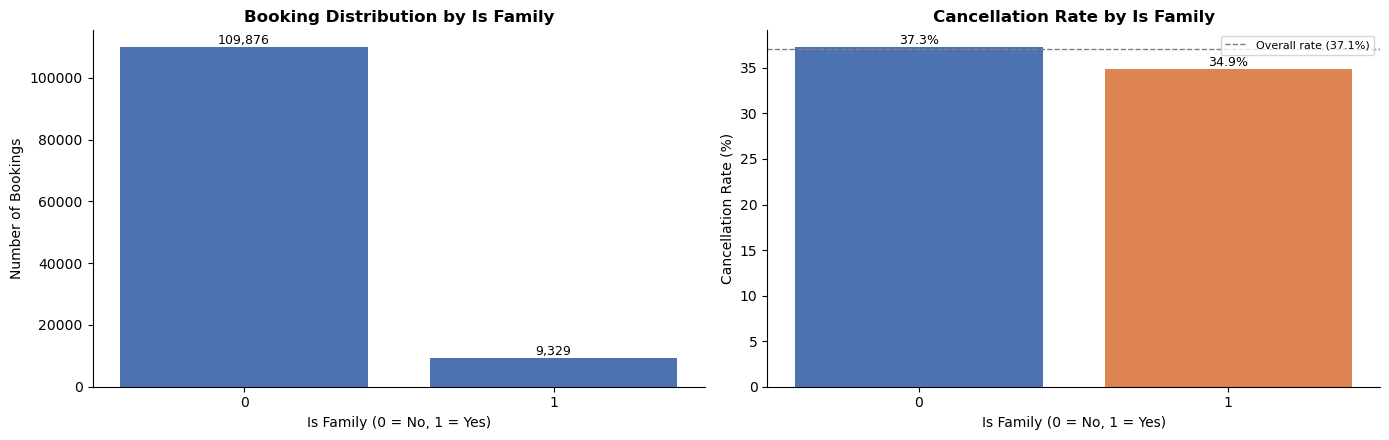

,is_family,booking_count,cancellation_rate
0,0,109876,37.26
1,1,9329,34.92


In [27]:
feature = "is_family"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Is Family", fontweight="bold")
ax[0].set_xlabel("Is Family (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Is Family", fontweight="bold")
ax[1].set_xlabel("Is Family (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Family Status Insight

- **Non-family mendominasi dengan 109.876 booking (92,2%)**, sedangkan family hanya 9.329 booking (7,8%).
- Cancellation rate non-family sebesar **37,3%**, dibandingkan **34,9%** pada family—selisih hanya 2,4 percentage points.
- **Kesimpulan:** status keluarga memiliki asosiasi yang sangat lemah dengan cancellation dan kemungkinan hanya memberi tambahan informasi terbatas secara individual.


##### **1.2.2.1.14 Cancellation Rate by Has Agent or Not**

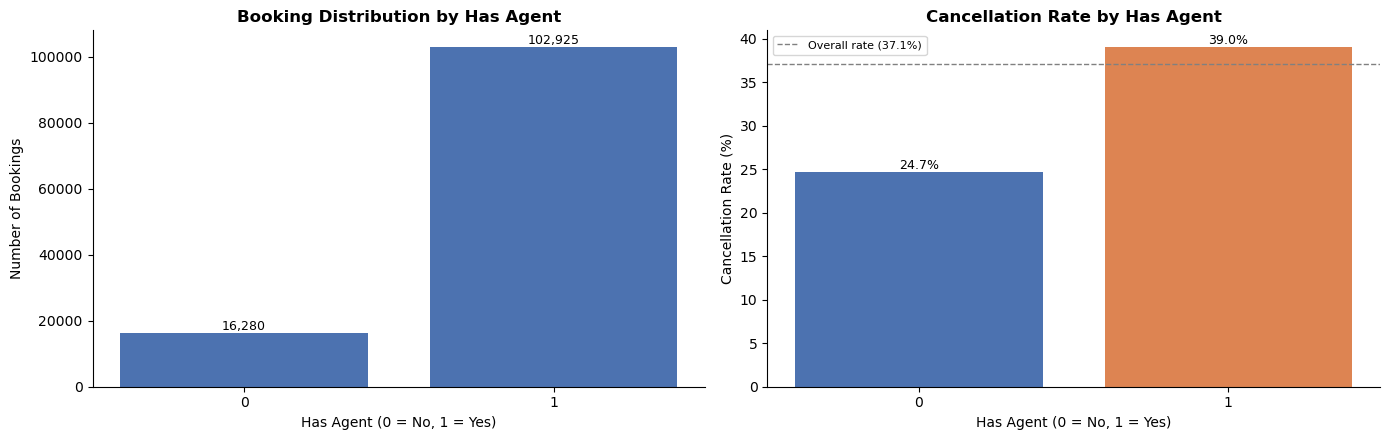

,has_agent,booking_count,cancellation_rate
0,0,16280,24.66
1,1,102925,39.04


In [28]:
feature = "has_agent"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Has Agent", fontweight="bold")
ax[0].set_xlabel("Has Agent (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Has Agent", fontweight="bold")
ax[1].set_xlabel("Has Agent (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Agent Usage Insight

- **Sebanyak 102.925 booking (86,3%) menggunakan agent**, sedangkan 16.280 booking (13,7%) tidak menggunakan agent.
- Booking dengan agent memiliki cancellation rate **39,0%**, lebih tinggi daripada booking tanpa agent sebesar **24,7%**.
- **Kesimpulan:** penggunaan agent berkaitan dengan rate yang lebih tinggi, tetapi hubungannya kemungkinan tumpang tindih dengan market segment dan distribution channel sehingga tidak boleh dibaca secara kausal.


##### **1.2.2.1.15 Cancellation Rate by Has Company or Not**

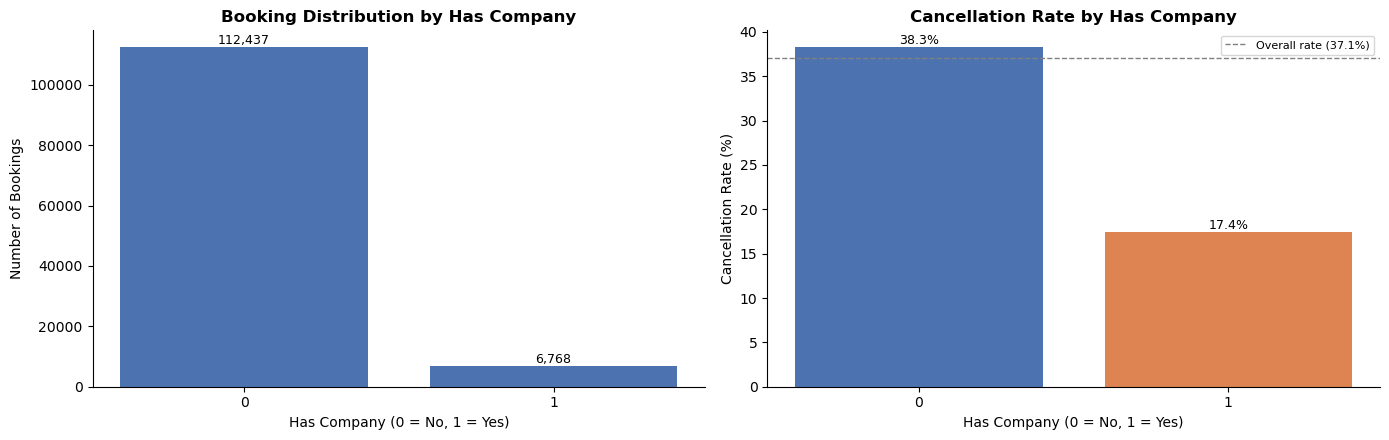

,has_company,booking_count,cancellation_rate
0,0,112437,38.26
1,1,6768,17.45


In [29]:
feature = "has_company"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Has Company", fontweight="bold")
ax[0].set_xlabel("Has Company (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Has Company", fontweight="bold")
ax[1].set_xlabel("Has Company (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Company Association Insight

- **Sebanyak 112.437 booking (94,3%) tidak terhubung dengan company**, sedangkan hanya 6.768 booking (5,7%) memiliki company.
- Booking dengan company memiliki cancellation rate **17,4%**, jauh di bawah booking tanpa company sebesar **38,3%**.
- **Kesimpulan:** company association memberikan indikasi booking yang lebih stabil, tetapi kategori company relatif kecil dan dapat berkaitan dengan customer type Corporate.


##### **1.2.2.1.16 Cancellation Rate by Room Type Changed or Not**

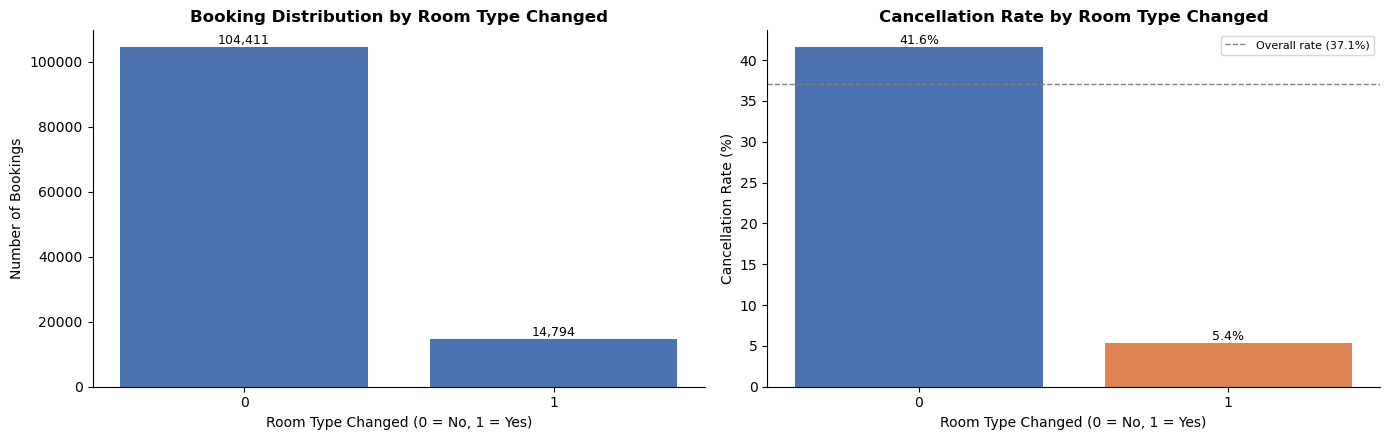

,room_type_changed,booking_count,cancellation_rate
0,0,104411,41.56
1,1,14794,5.41


In [30]:
feature = "room_type_changed"

seg_stats = (
    df.groupby(feature, observed=True)["is_canceled"]
      .agg(booking_count="size", cancellation_rate="mean")
      .reset_index()
)
seg_stats["cancellation_rate"] *= 100
overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: jumlah booking
bars_count = ax[0].bar(
    seg_stats[feature].astype(str),
    seg_stats["booking_count"],
    color=["#4C72B0"][:len(seg_stats)]
)
for bar, value in zip(bars_count, seg_stats["booking_count"]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax[0].set_title("Booking Distribution by Room Type Changed", fontweight="bold")
ax[0].set_xlabel("Room Type Changed (0 = No, 1 = Yes)")
ax[0].set_ylabel("Number of Bookings")
ax[0].spines[["top", "right"]].set_visible(False)

# Panel 2: cancellation rate
bars_rate = ax[1].bar(
    seg_stats[feature].astype(str),
    seg_stats["cancellation_rate"],
    color=["#4C72B0", "#DD8452"][:len(seg_stats)]
)
for bar, value in zip(bars_rate, seg_stats["cancellation_rate"]):
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )
ax[1].axhline(
    overall_rate,
    color="gray", linestyle="--", linewidth=1,
    label=f"Overall rate ({overall_rate:.1f}%)"
)
ax[1].set_title("Cancellation Rate by Room Type Changed", fontweight="bold")
ax[1].set_xlabel("Room Type Changed (0 = No, 1 = Yes)")
ax[1].set_ylabel("Cancellation Rate (%)")
ax[1].legend(fontsize=8)
ax[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

display(seg_stats.round({"cancellation_rate": 2}))


Cancellation Rate by Room Type Change Insight

- **Sebanyak 104.411 booking (87,6%) tidak mengalami perubahan kamar**, sedangkan 14.794 booking (12,4%) mengalami perubahan.
- Cancellation rate booking tanpa perubahan kamar sebesar **41,6%**, dibandingkan hanya **5,4%** pada booking dengan perubahan kamar.
- **Modeling Implication:** perbedaan ini sangat tajam, tetapi `room_type_changed` berpotensi merupakan informasi pasca-booking. Fitur harus dikeluarkan apabila belum tersedia pada waktu prediksi untuk mencegah leakage.


#### **1.2.2.2 High Cardinality Features**

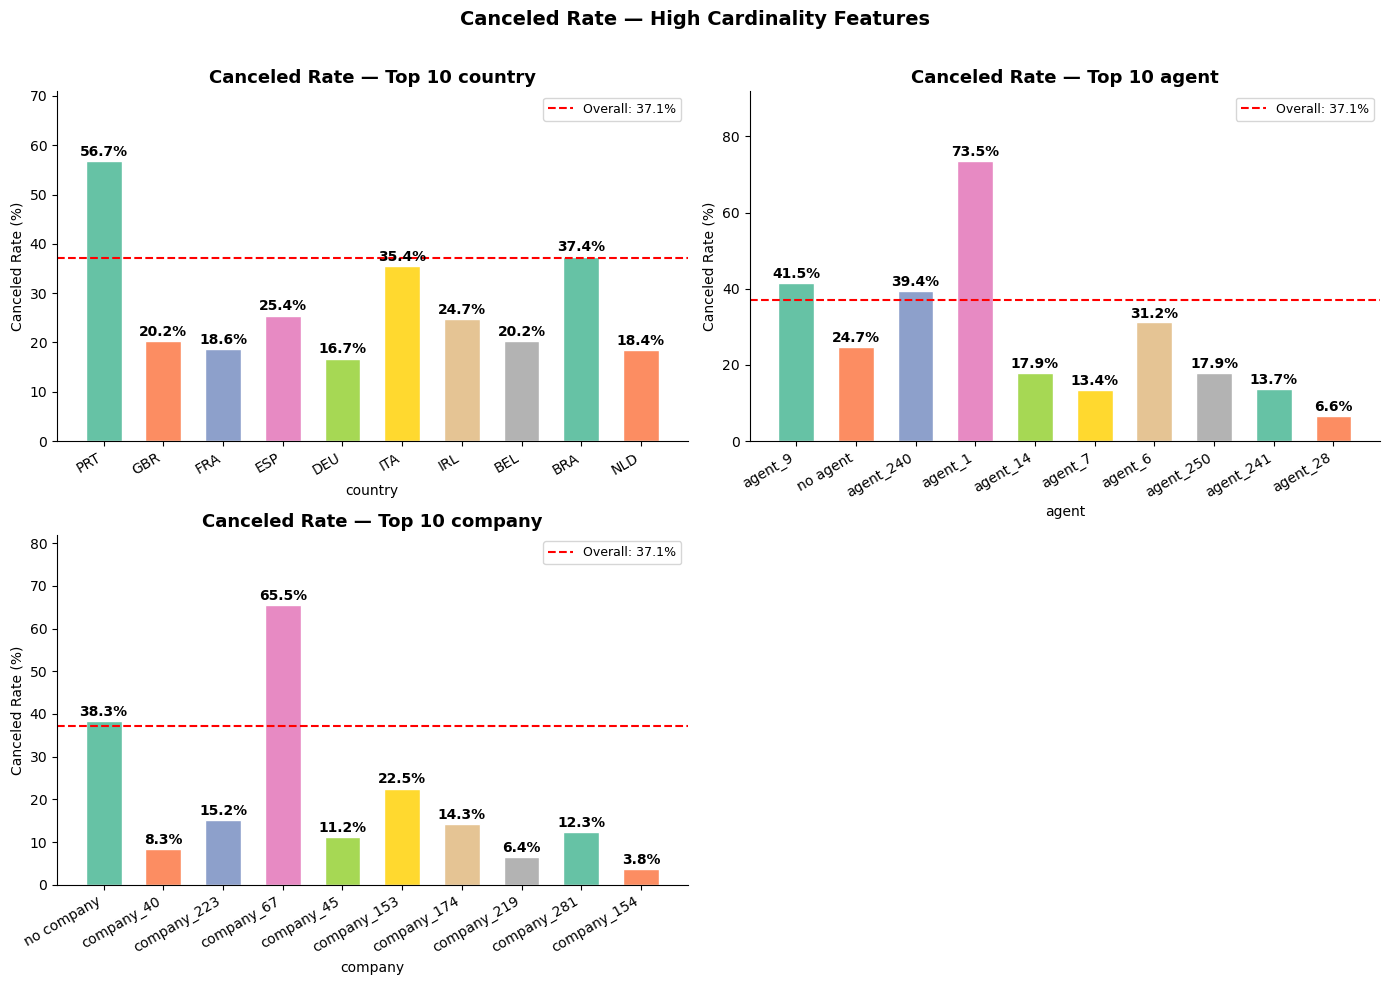

In [31]:
high_card_cols = [
    col for col in cat_cols
    if df[col].nunique() > 15
]

n_cols = 2
n_rows = math.ceil(len(high_card_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = np.atleast_1d(axes).flatten()

overall_rate = df["is_canceled"].mean() * 100

for ax, col in zip(axes, high_card_cols):

    cancel_stats = (
        df.groupby(col)["is_canceled"]
        .agg(["mean", "count"])
        .query("count >= 100")
        .sort_values("count", ascending=False)
        .head(10)
    )

    canceled_rate = cancel_stats["mean"] * 100

    bars = ax.bar(
        canceled_rate.index.astype(str),
        canceled_rate.values,
        color=sns.color_palette("Set2", len(canceled_rate)),
        edgecolor="white",
        width=0.6
    )

    for bar, v in zip(bars, canceled_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.5,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.axhline(
        overall_rate,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Overall: {overall_rate:.1f}%"
    )

    ax.set_title(
        f"Canceled Rate — Top 10 {col}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Canceled Rate (%)")
    ax.set_ylim(0, canceled_rate.max() * 1.25)

    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha="right"
    )

for j in range(len(high_card_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Canceled Rate — High Cardinality Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

##### Canceled Rate — High Cardinality Features Insight

- **Negara asal menunjukkan variasi cancellation yang besar.** Di antara sepuluh negara dengan volume terbesar, PRT memiliki rate tertinggi (56,7%), diikuti BRA (37,4%) dan ITA (35,4%). Negara lain berada di bawah overall rate 37,1%, termasuk ESP 25,4%, IRL 24,7%, serta GBR dan BEL 20,2%.

- **Agent 1 menunjukkan cancellation rate tertinggi sebesar 73,5%**, tetapi keandalan perbandingan perlu dibaca bersama jumlah booking setiap agent. Agent 9 memiliki rate 41,5%, sedangkan no agent 24,7% dan Agent 28 hanya 6,6%.

- **Company 67 memiliki rate tertinggi sebesar 65,5%**, sementara no company berada sedikit di atas overall rate dengan 38,3%. Sebagian besar company lain memiliki rate jauh lebih rendah, tetapi volumenya sangat kecil.

- **`agent` dan `company` adalah identifier berkardinalitas tinggi.** Rentang rate yang lebar tidak boleh langsung dianggap sebagai daya prediksi yang stabil. Jika target encoding digunakan, perhitungannya wajib dilakukan hanya di dalam training fold untuk mencegah leakage.

- **Modeling Implication:** tampilkan count bersama rate, gabungkan kategori langka berdasarkan data training, dan hindari duplikasi `agent`/`company` dengan `has_agent`/`has_company` tanpa menguji manfaat tambahannya.


##### High Cardinality Features vs Target — Chi-Square Test + Cramér's V

Chi-square test langsung terhadap `country`, `agent`, dan `company` dalam bentuk aslinya tidak layak karena banyak kategori punya count sangat kecil.

Untuk menjaga validitas uji, setiap fitur di-bucket: kategori dengan volume terbesar dipertahankan (top 10), sisanya digabung jadi kategori **"Other"**. Pendekatan ini konsisten dengan penanganan rare category yang sudah disebutkan pada narasi target encoding di bagian modeling.

In [32]:
def bucket_rare_categories(series, top_n=10, other_label='Other'):
    """Kelompokkan kategori di luar top_n paling sering menjadi satu label 'Other'."""
    top_categories = series.value_counts().head(top_n).index
    return series.where(series.isin(top_categories), other_label)

high_card_test_cols = ['country', 'agent', 'company']
high_card_chi2_results = []

for col in high_card_test_cols:
    bucketed = bucket_rare_categories(df[col].astype(str), top_n=15)
    ct = pd.crosstab(bucketed, df['is_canceled'])

    chi2, p, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v(ct)  # fungsi ini sudah didefinisikan di cell 34
    min_expected = expected.min()
    n_categories_after_bucket = bucketed.nunique()
    n_categories_original = df[col].nunique()

    high_card_chi2_results.append([
        col, n_categories_original, n_categories_after_bucket,
        chi2, p, v, min_expected
    ])

high_card_chi2_df = pd.DataFrame(
    high_card_chi2_results,
    columns=['feature', 'n_categories_original', 'n_categories_after_bucket',
             'chi2_statistic', 'p_value', 'cramers_v', 'min_expected_count']
).sort_values('cramers_v', ascending=False).reset_index(drop=True)

high_card_chi2_df

,feature,n_categories_original,n_categories_after_bucket,chi2_statistic,p_value,cramers_v,min_expected_count
0,country,178,16,14565.070548,0.0,0.349550,378.179942
1,agent,334,16,9963.592701,0.0,0.289108,385.224470
2,company,349,16,1528.334649,0.0,0.113230,26.324290


##### Chi-Square Test Insight

- **`country` memiliki asosiasi terkuat di antara ketiga fitur high-cardinality (Cramér's V=0,350)**, mendekati level `market_segment` (V=0,267) dari fitur low-cardinality, dan lebih kuat dari `assigned_room_type` (V=0,247). `agent` menyusul di V=0,289.

- **`company` memiliki asosiasi paling lemah (V=0,113)** di antara ketiganya, masih lebih kuat dari sebagian besar fitur low-cardinality , tetapi jauh di bawah `country` dan `agent`.

- **Semua expected cell count berada jauh di atas ambang 5** (minimum 26,3 pada `company`, 378–385 pada `country` dan `agent`), berbeda dari beberapa fitur low-cardinality yang melanggar asumsi ini. Bucketing top-10 + "Other" berhasil membuat ketiga uji ini valid secara asumsi, sekaligus menurunkan jumlah kategori dari 178–349 menjadi 16.

- **Cramér's V di sini bukan angka bersih**. Kategori "Other" pada setiap fitur menggabungkan puluhan hingga ratusan kategori asli dengan cancellation rate yang sangat bervariasi. Asosiasi teramati sebagian didorong oleh kategori besar spesifik (PRT untuk `country`), sebagian oleh efek gabungan "Other" yang tidak bisa diurai lebih lanjut dari uji ini saja.

- **Modeling Implication:** ketiga fitur, terutama `country` dan `agent`, layak dipertimbangkan sebagai fitur bernilai meski high-cardinality, tapi metode encoding (target encoding, dsb.) tetap wajib dihitung hanya di training fold untuk mencegah leakage. Cramér's V di sini mengukur asosiasi keseluruhan, bukan kontribusi kategori individual.

##### **1.2.2.2.1 Cancellation Rate by Top 10 Country**

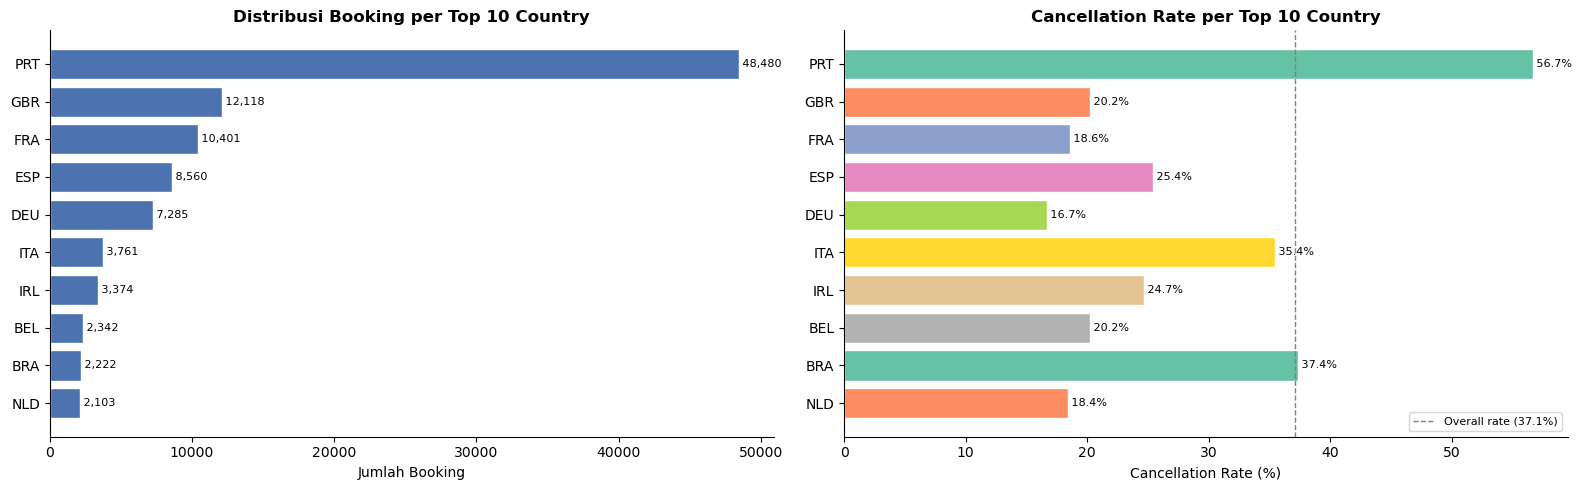

In [33]:
seg_stats = df.groupby('country', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Top 10 Country', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Top 10 Country', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

##### Cancellation Rate by Top 10 Country Insight

- **Portugal (PRT) menjadi negara dengan risiko cancellation paling material**, karena memiliki volume booking terbesar sebanyak **48.480 booking** sekaligus cancellation rate tertinggi sebesar **56,7%**. Nilai ini **19,6** percentage points di atas overall cancellation rate sebesar **37,1%**.

- **Brasil (BRA) memiliki cancellation rate sebesar 37,4%**, hampir sama dengan overall rate. Namun, volumenya hanya **2.222 booking**, sehingga kontribusinya terhadap jumlah pembatalan jauh lebih kecil dibandingkan Portugal.

- **Italia (ITA) mencatat cancellation rate sebesar 35,4%**, tertinggi ketiga di antara sepuluh negara tersebut, tetapi masih sedikit di bawah overall rate. Italia juga hanya menyumbang **3.761 booking**.

- **Negara dengan volume besar selain Portugal memiliki cancellation rate relatif rendah**. Inggris (GBR) mencatat **12.118 booking** dengan rate **20,2%**, Prancis (FRA) **10.401 booking** dengan rate **18,6%**, Spanyol (ESP) **8.560 booking** dengan rate **25,4%**, dan Jerman (DEU) **7.285 booking** dengan rate **16,7%**.

- **Jerman memiliki cancellation rate terendah sebesar 16,7%**, diikuti Belanda sebesar **18,4% **dan Prancis sebesar **18,6%**. Ketiganya menunjukkan tingkat cancellation kurang dari setengah atau sekitar setengah overall rate.

- **Business Impliatcion**: pengelolaan risiko berdasarkan negara sebaiknya diprioritaskan pada booking dari Portugal karena menggabungkan volume terbesar dan cancellation rate yang jauh di atas rata-rata. Namun, sebelum melakukan intervensi berdasarkan negara, pola Portugal perlu dianalisis bersama `deposit_type`, `market_segment`, `agent`, dan `lead_time` karena negara kemungkinan menjadi indikator dari karakteristik booking lain, bukan penyebab langsung cancellation.

##### **1.2.2.2.2 Cancellation Rate by Top 10 Agent**

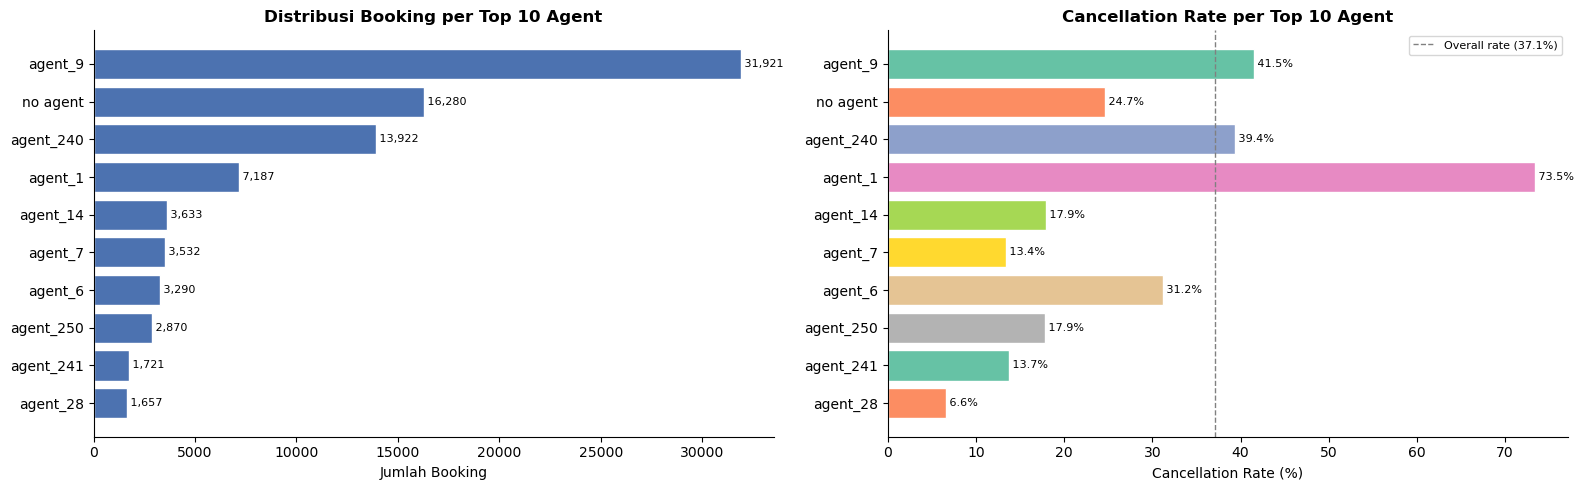

In [34]:
seg_stats = df.groupby('agent', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Top 10 Agent', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Top 10 Agent', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

##### Cancellation Rate by Top 10 Agent Insight
- **`Agent 9` menjadi sumber booking terbesar sekaligus memiliki cancellation rate di atas rata-rata**. Agent ini menangani **31.921 booking** dengan cancellation rate **41,5%**, lebih tinggi **4,4 percentage points** dibandingkan overall rate sebesar **37,1%**. Kombinasi volume besar dan rate tinggi menjadikan `Agent 9` kontributor utama terhadap jumlah cancellation.

- **`Agent 1` menunjukkan risiko cancellation tertinggi, yaitu 73,5% dari 7.187 booking**. Karena volumenya cukup material, tingginya rate ini bukan sekadar akibat kategori yang sangat kecil dan perlu menjadi prioritas utama untuk ditelusuri lebih lanjut.

- **`Agent 240` juga perlu diperhatikan, karena memiliki volume terbesar ketiga sebanyak 13.922 booking dan cancellation rate 39,4%**, sedikit di atas overall rate. Meskipun tidak setinggi Agent 1, volume yang besar membuat dampaknya terhadap total cancellation tetap signifikan.

- **Booking tanpa agent memiliki cancellation rate relatif rendah**. Dari **16.280 booking** tanpa agent, hanya **24,7%** yang dibatalkan. Nilai ini **12,4 percentage points** di bawah overall rate dan jauh lebih rendah dibandingkan `Agent 9`, `Agent 240`, serta `Agent 1`.

- **Beberapa agent menunjukkan booking yang lebih stabil**. `Agent 28` memiliki cancellation rate terendah sebesar **6,6%**, diikuti `Agent 7` sebesar **13,4%**, `Agent 241` sebesar **13,7%**, serta `Agent 14` dan `Agent 250` masing-masing sebesar **17,9%**. Namun, volume mereka lebih kecil sehingga dampaknya terhadap keseluruhan booking lebih terbatas.

**Business Implication:** `Agent 1` menjadi prioritas utama dari sisi tingkat risiko, sedangkan `Agent 9` dan `Agent 240 `perlu diprioritaskan karena menggabungkan cancellation rate di atas rata-rata dengan volume booking besar. Hotel dapat meninjau karakteristik booking dari ketiga agent tersebut, seperti `lead_time`, `deposit_type`, `market_segment`, dan kebijakan pembatalannya sebelum menentukan tindakan.

##### **1.2.2.2.3 Cancellation Rate by Top 10 Company**

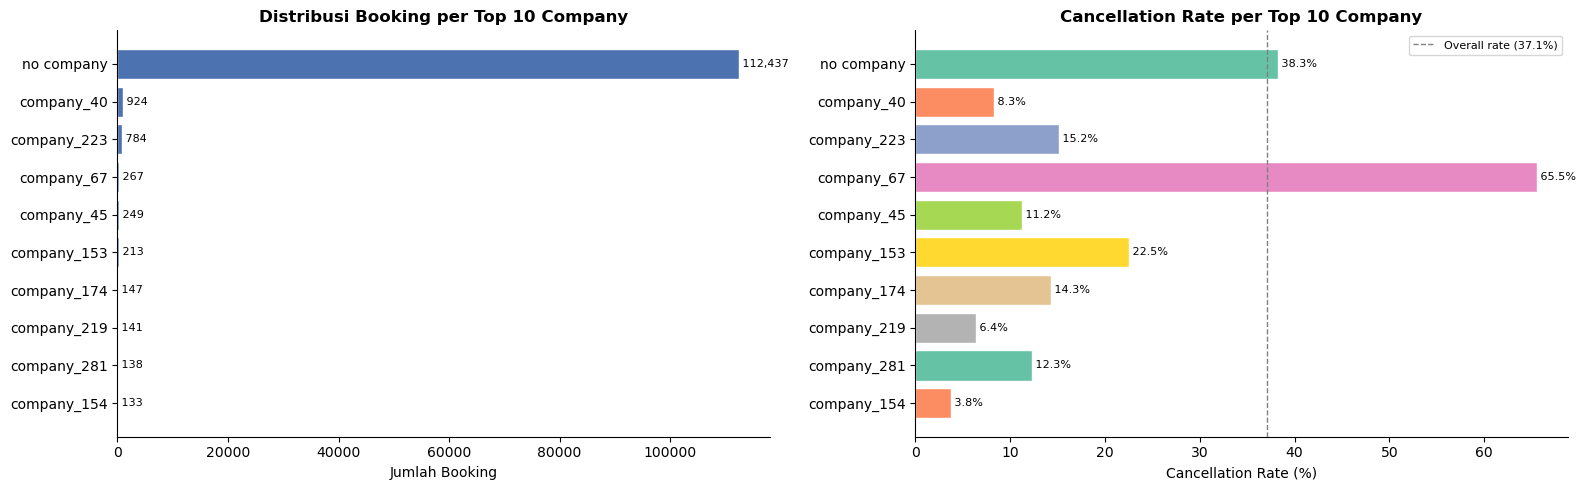

In [35]:
seg_stats = df.groupby('company', observed=True)['is_canceled'].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
seg_stats['mean'] = seg_stats['mean'] * 100
overall_rate = df['is_canceled'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

bars0 = ax[0].barh(seg_stats.index, seg_stats['count'], color='#4C72B0', edgecolor='white')
for bar, v in zip(bars0, seg_stats['count']):
    ax[0].text(v, bar.get_y() + bar.get_height() / 2, f" {v:,}", va='center', fontsize=8)
ax[0].invert_yaxis()
ax[0].set_title('Distribusi Booking per Top 10 Company', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Jumlah Booking')
ax[0].spines[['top', 'right']].set_visible(False)

colors = sns.color_palette("Set2", len(seg_stats))
bars1 = ax[1].barh(seg_stats.index, seg_stats['mean'], color=colors, edgecolor='white')
for bar, v in zip(bars1, seg_stats['mean']):
    ax[1].text(v, bar.get_y() + bar.get_height() / 2, f" {v:.1f}%", va='center', fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate:.1f}%)')
ax[1].set_title('Cancellation Rate per Top 10 Company', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Cancellation Rate (%)')
ax[1].legend(fontsize=8)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

##### Cancellation Rate by Top 10 Company Insight
- **Mayoritas booking tidak terhubung dengan perusahaan**, yaitu sebanyak **112.437 booking** atau **94,3%** dari seluruh reservasi. Kelompok no company memiliki cancellation rate *38,3%*, sedikit lebih tinggi daripada overall rate sebesar **37,1%**. Karena volumenya sangat dominan, kelompok ini menjadi kontributor terbesar terhadap jumlah cancellation secara keseluruhan.

- **`Company 67` memiliki cancellation rate tertinggi sebesar 65,5%, jauh di atas overall rate**. Namun, company ini hanya mencakup **267 booking**, sehingga dampaknya terhadap total cancellation lebih kecil daripada kelompok no company dan estimasi rate-nya lebih sensitif terhadap perubahan data.

- **Seluruh company lainnya memiliki cancellation rate di bawah rata-rata**. `Company 153` memiliki rate **22,5%**, diikuti `Company 223` sebesar **15,2%**, `Company 174` sebesar **14,3%**, `Company 281` sebesar **12,3%**, dan `Company 45` sebesar **11,2%**.

- **`Company 40` menjadi perusahaan dengan volume booking terbesar, yaitu 924 booking**, tetapi cancellation rate-nya hanya **8,3%**. Nilai ini jauh di bawah overall rate dan menunjukkan tingkat pembatalan yang relatif rendah pada company dengan volume terbesar.

- **Cancellation rate terendah ditemukan pada Company 154, yaitu sebesar 3,8% dari 133 booking, diikuti Company 219 sebesar 6,4% dari 141 booking**. Namun, volume keduanya sangat kecil sehingga hasilnya perlu dibaca secara hati-hati.
Distribusi company sangat tidak seimbang. Tidak ada satu company pun yang menyumbang lebih dari 1% total booking, sementara no company mencakup **94,3%**. Oleh karena itu, perbedaan rate antar-company tidak selalu memiliki dampak bisnis yang besar meskipun secara persentase terlihat tajam.

- **Business Implication:** tingginya cancellation rate `Company 67 `perlu ditelusuri, tetapi prioritas operasional tidak boleh ditentukan hanya berdasarkan rate. Hotel perlu mempertimbangkan jumlah booking dan cancellation secara bersamaan. `Company 40` lebih relevan sebagai pembanding karena memiliki volume terbesar dengan tingkat cancellation yang rendah.

## **1.3 Multivariate Analysis**
### **1.3.1 Cancel Rate: Deposit Type x Market Segment**

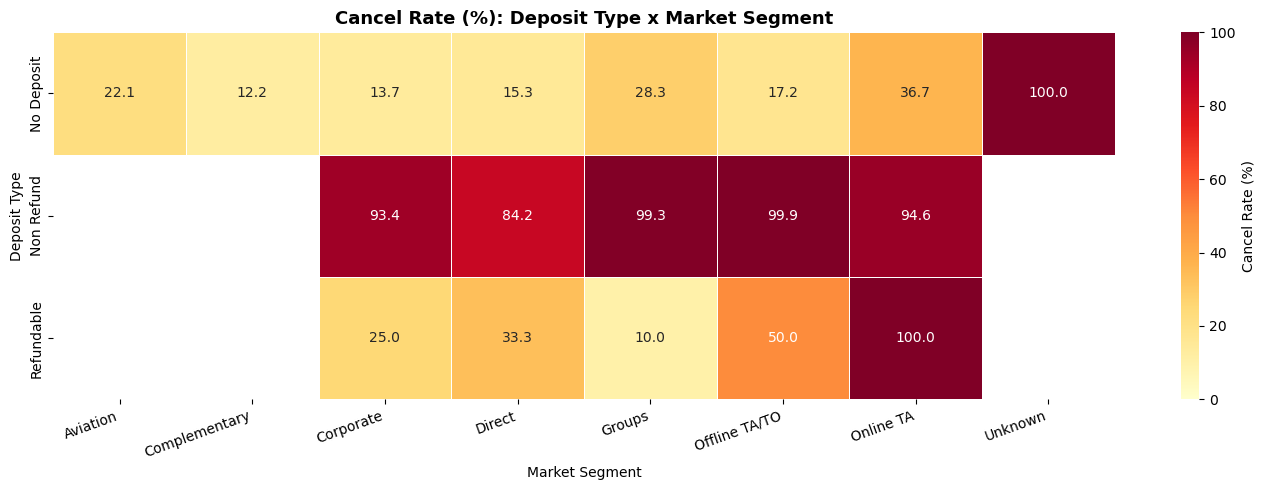

In [36]:
pivot_deposit_segment = df.pivot_table(
    values='is_canceled', index='deposit_type', columns='market_segment', aggfunc='mean'
) * 100

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_deposit_segment, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', vmin=0, vmax=100,
            cbar_kws={'label': 'Cancel Rate (%)'})
plt.title('Cancel Rate (%): Deposit Type x Market Segment', fontsize=13, fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Deposit Type')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

#### Deposit Type × Market Segment Insight

- **Non Refund memiliki cancellation rate sangat tinggi pada hampir semua market segment yang terisi:** Offline TA/TO 99,9%, Groups 99,3%, Online TA 94,6%, Corporate 93,4%, dan Direct 84,2%.

- **Pada No Deposit, cancellation rate jauh lebih rendah**, dari 12,2% pada Complementary sampai 36,7% pada Online TA. Unknown mencapai 100%, tetapi kategorinya sangat kecil.

- **Refundable memiliki variasi besar**, mulai dari 10,0% pada Groups sampai 100% pada Online TA. Karena total Refundable hanya 162 booking, rate setiap kombinasi sangat sensitif terhadap sample size.

- **Chart kiri hanya menunjukkan rate, bukan volume per kombinasi.** Karena itu, materialitas bisnis setiap sel belum dapat ditentukan tanpa tabel jumlah booking. Temuan ini menunjukkan interaksi yang perlu diperiksa, bukan bukti bahwa Non Refund menyebabkan pembatalan.


### **1.3.2 Cancel Rate: Deposit Type x Country (Top Countries)**

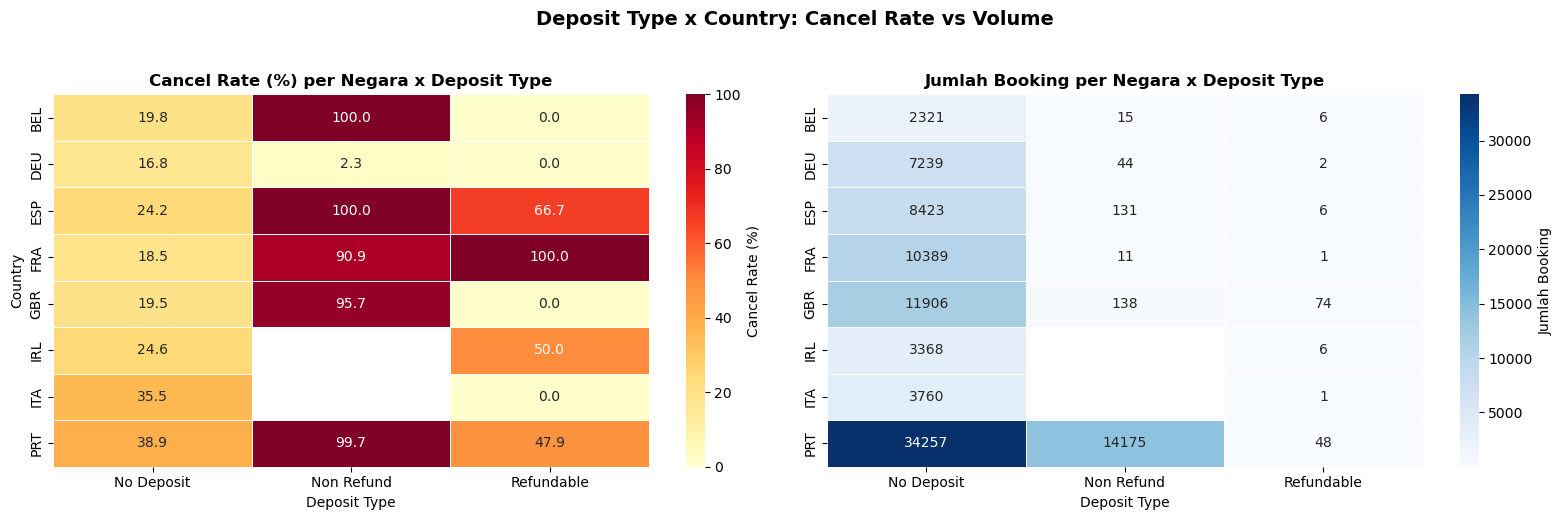

In [37]:
top_countries = df['country'].value_counts().head(8).index.tolist()
sub = df[df['country'].isin(top_countries)]

pivot_deposit_country = sub.pivot_table(
    values='is_canceled', index='country', columns='deposit_type', aggfunc='mean'
) * 100
count_deposit_country = sub.pivot_table(
    values='is_canceled', index='country', columns='deposit_type', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_deposit_country, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', vmin=0, vmax=100,
            cbar_kws={'label': 'Cancel Rate (%)'}, ax=axes[0])
axes[0].set_title('Cancel Rate (%) per Negara x Deposit Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Deposit Type')
axes[0].set_ylabel('Country')

sns.heatmap(count_deposit_country, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Jumlah Booking'}, ax=axes[1])
axes[1].set_title('Jumlah Booking per Negara x Deposit Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Deposit Type')
axes[1].set_ylabel('')

plt.suptitle('Deposit Type x Country: Cancel Rate vs Volume', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

#### Deposit Type × Country Insight

- **Portugal (PRT) mendominasi volume Non Refund**, dengan 14.175 booking dan cancellation rate 99,7%. Kombinasi ini jauh lebih material daripada negara lain pada chart.

- **BEL dan ESP sama-sama memiliki rate 100% pada Non Refund**, tetapi volumenya hanya 15 dan 131 booking. Keduanya tidak dapat disebut mendominasi volume.

- **DEU menunjukkan pola berbeda**, dengan hanya 1 cancellation dari 44 booking Non Refund atau rate 2,3%.

- **No Deposit memiliki volume terbesar pada hampir semua negara**, tetapi rate-nya jauh lebih rendah dibandingkan Non Refund. Interpretasi perlu mempertimbangkan ketimpangan ukuran sampel antartipe deposit dan antarnegara.

- **Business Implication:** pola Non Refund secara agregat terutama dipengaruhi PRT, bukan BEL atau ESP. Analisis lanjutan perlu memeriksa hubungan PRT dengan agent dan market segment sebelum membuat kebijakan deposit.


#### Two-Proportion Z-Test — Validasi Deposit × Country

Section 1.3.2 menunjukkan bahwa cancellation rate Non Refund berbeda tajam antara DEU, BEL, dan ESP. Two-proportion z-test digunakan untuk menguji apakah rate DEU berbeda secara statistik dari BEL dan ESP. Pengujian ini tidak digunakan untuk menentukan negara dengan volume terbesar; informasi volume harus dibaca langsung dari tabel jumlah booking.


In [38]:
sub = df[(df['deposit_type'] == 'Non Refund') & (df['country'].isin(['DEU', 'BEL', 'ESP']))]
grp = sub.groupby('country')['is_canceled'].agg(['sum', 'count'])
grp['cancel_rate_%'] = (grp['sum'] / grp['count'] * 100).round(1)
print(grp)
print()

for other in ['BEL', 'ESP']:
    count = np.array([grp.loc['DEU', 'sum'], grp.loc[other, 'sum']])
    nobs = np.array([grp.loc['DEU', 'count'], grp.loc[other, 'count']])
    z, p = proportions_ztest(count, nobs)
    print(f"DEU (n={nobs[0]}) vs {other} (n={nobs[1]}): z={z:.3f}, p={p:.4f}")

         sum  count  cancel_rate_%
country                           
BEL       15     15          100.0
DEU        1     44            2.3
ESP      131    131          100.0

DEU (n=44) vs BEL (n=15): z=-7.352, p=0.0000
DEU (n=44) vs ESP (n=131): z=-13.028, p=0.0000


#### Two-Proportion Z-Test Insight

- **Ukuran sampel aktual adalah DEU=44, BEL=15, dan ESP=131 booking Non Refund.** Cancellation masing-masing adalah 1, 15, dan 131, sehingga rate-nya 2,3%, 100%, dan 100%.

- **Perbedaan DEU dengan BEL dan ESP signifikan secara statistik** (keduanya p<0,001). Namun, hasil tersebut tidak berarti BEL dan ESP mendominasi volume; PRT tetap memiliki volume Non Refund terbesar dengan 14.175 booking.

- **Hasil perlu dibaca bersama sample size dan konteks.** BEL hanya memiliki 15 observasi, sedangkan rate 100% pada BEL dan ESP dapat mencerminkan pola agent atau market segment tertentu. Z-test menunjukkan perbedaan proporsi, bukan hubungan sebab-akibat.


### **1.3.3 Interaksi Lead Time x Deposit Type terhadap Cancel**

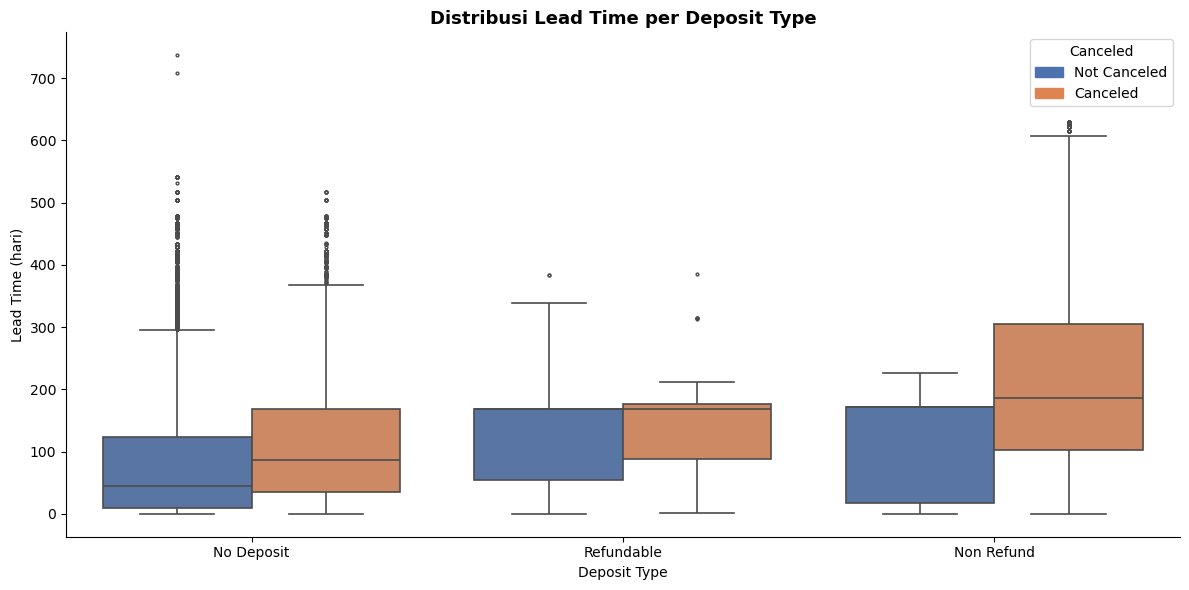

In [39]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='deposit_type', y='lead_time', hue='is_canceled',
                  palette={0: '#4C72B0', 1: '#DD8452'},
                  fliersize=2, linewidth=1.2)

handles = [
    mpatches.Patch(color='#4C72B0', label='Not Canceled'),
    mpatches.Patch(color='#DD8452', label='Canceled'),
]
ax.legend(handles=handles, title='Canceled')

plt.title('Distribusi Lead Time per Deposit Type', fontsize=13, fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Lead Time (hari)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Lead Time × Deposit Type Insight

- **Pada No Deposit, kelompok Canceled memiliki median lead time lebih tinggi** daripada Not Canceled dan distribusi yang lebih lebar. Pola ini menunjukkan perbedaan lead time yang jelas pada kategori dengan volume terbesar.

- **Pada Refundable, median kedua kelas relatif berdekatan dan IQR saling tumpang tindih.** Karena Refundable hanya berisi 162 booking, pola ini tidak stabil untuk digeneralisasi.

- **Pada Non Refund, kelompok Canceled juga memiliki median lead time lebih tinggi dan IQR lebih lebar** daripada Not Canceled. Namun, kelompok Not Canceled pada kategori ini jauh lebih kecil karena overall rate Non Refund mencapai 99,4%.

- **Kesimpulan:** hubungan lead time dengan cancellation berbeda menurut deposit type. Boxplot mendukung adanya interaksi, tetapi perlu dilengkapi count dan ringkasan median per kelompok agar besarnya perbedaan tidak hanya diperkirakan secara visual.


#### Lead Time × Deposit Type — Kruskal-Wallis Test + Dunn's Post-Hoc

Boxplot menunjukkan indikasi perbedaan distribusi `lead_time` antar tiga kategori `deposit_type`. Karena `lead_time` non-normal dan jumlah grup lebih dari dua, digunakan **Kruskal-Wallis H test** sebagai versi non-parametrik dari one-way ANOVA.

Karena Kruskal-Wallis hanya menguji apakah *minimal ada satu* grup yang berbeda tanpa menunjukkan pasangan mana yang berbeda, dilanjutkan dengan **Dunn's post-hoc test** (koreksi Bonferroni) untuk perbandingan berpasangan antar ketiga kategori deposit type.

In [40]:
# Kruskal-Wallis H test: lead_time across deposit_type groups
groups = [g['lead_time'].values for _, g in df.groupby('deposit_type', observed=True)]
group_labels = df['deposit_type'].cat.categories if hasattr(df['deposit_type'], 'cat') else df['deposit_type'].unique()

h_stat, p_kw = stats.kruskal(*groups)

n_total = len(df)
k_groups = len(groups)
eta_sq_h = (h_stat - k_groups + 1) / (n_total - k_groups)  # epsilon-squared, effect size utk Kruskal-Wallis

print(f"Kruskal-Wallis H = {h_stat:.4f}, p-value = {p_kw:.6f}")
print(f"Epsilon-squared (effect size) = {eta_sq_h:.4f}")

# Dunn's post-hoc test dengan koreksi Bonferroni
try:
    import scikit_posthocs as sp
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'scikit-posthocs', '--break-system-packages', '-q'])
    import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(
    df, val_col='lead_time', group_col='deposit_type', p_adjust='bonferroni'
)
dunn_result

Kruskal-Wallis H = 13098.1524, p-value = 0.000000
Epsilon-squared (effect size) = 0.1099


,No Deposit,Non Refund,Refundable
No Deposit,1.000000e+00,0.000000,3.112545e-16
Non Refund,0.000000e+00,1.000000,1.839922e-05
Refundable,3.112545e-16,0.000018,1.000000e+00


#### Kruskal-Wallis + Dunn's Post-Hoc Insight

- **Kruskal-Wallis signifikan secara statistik (H=13.098,15; p<0,0001)** dengan epsilon-squared 0,110 — tergolong **efek sedang** (antara ambang 0,06 dan 0,14), bukan hanya artefak ukuran sampel besar. Ini konsisten dengan `lead_time` sebagai fitur numerik dengan effect size terbesar pada Section 1.2.1 (rank-biserial |r|=0,378 terhadap `is_canceled`), sekarang terkonfirmasi juga berbeda signifikan antar ketiga kategori `deposit_type`.

- **Dunn's post-hoc menunjukkan ketiga pasangan signifikan setelah koreksi Bonferroni**: No Deposit vs Non Refund (p≈0), No Deposit vs Refundable (p=3,11×10⁻¹⁶), dan Non Refund vs Refundable (p=1,84×10⁻⁵). Tidak ada pasangan yang gagal menolak H0.

- **Dunn's test hanya memberi p-value, bukan besaran/arah perbedaan.** Signifikan di ketiga pasangan tidak memberi tahu pasangan mana yang gap-nya paling besar secara praktis.

- **Pasangan Refundable tetap perlu dibaca hati-hati.** Kedua p-value yang melibatkan Refundable (vs No Deposit dan vs Non Refund) signifikan, tapi kategori ini hanya berisi 162 booking.

- **Modeling Implication:** hasil ini memperkuat bahwa interaksi `lead_time × deposit_type` berbeda signifikan secara statistik dengan efek sedang. Kombinasi kedua fitur layak dipertimbangkan, bukan hanya masing-masing fitur secara terpisah.

### **1.3.4 Relasi Market Segment x Distribution Channel**

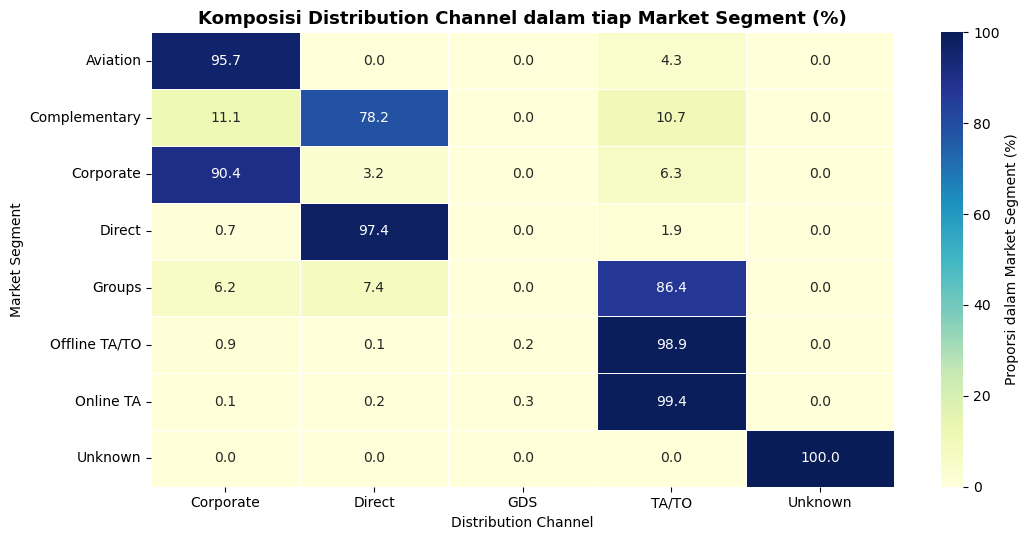

In [41]:
ct_pct = pd.crosstab(df['market_segment'], df['distribution_channel'], normalize='index') * 100

plt.figure(figsize=(11, 5.5))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', vmin=0, vmax=100,
            cbar_kws={'label': 'Proporsi dalam Market Segment (%)'})
plt.title('Komposisi Distribution Channel dalam tiap Market Segment (%)', fontsize=13, fontweight='bold')
plt.xlabel('Distribution Channel')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.show()

#### Market Segment × Distribution Channel Insight

- **Sebagian besar market segment sangat terkonsentrasi pada satu distribution channel.** Online TA (99,4%) dan Offline TA/TO (98,9%) hampir seluruhnya melalui TA/TO, Direct 97,4% melalui Direct, Aviation 95,7% melalui Corporate, dan Corporate 90,4% melalui Corporate.

- **Groups lebih beragam dibandingkan segmen utama lainnya**, tetapi tetap didominasi TA/TO sebesar 86,4%. Complementary terutama melalui Direct sebesar 78,2%, dengan sisanya tersebar pada Corporate dan TA/TO.

- **Kesimpulan:** `market_segment` dan `distribution_channel` membawa informasi yang sangat tumpang tindih. Pada model linear setelah one-hot encoding, redundansi ini dapat mengganggu stabilitas koefisien; pada model tree-based dampaknya lebih kecil, tetapi tetap memengaruhi interpretasi feature importance.

- **Modeling Implication:** uji performa dan interpretabilitas ketika kedua fitur digunakan bersama versus hanya salah satunya. Hubungan kategorikal ini tidak dinilai oleh VIF numerik pada Section 1.4.


## **1.4 Correlation & Multicollinearity Check**
### **1.4.1 Correlation Heatmap**

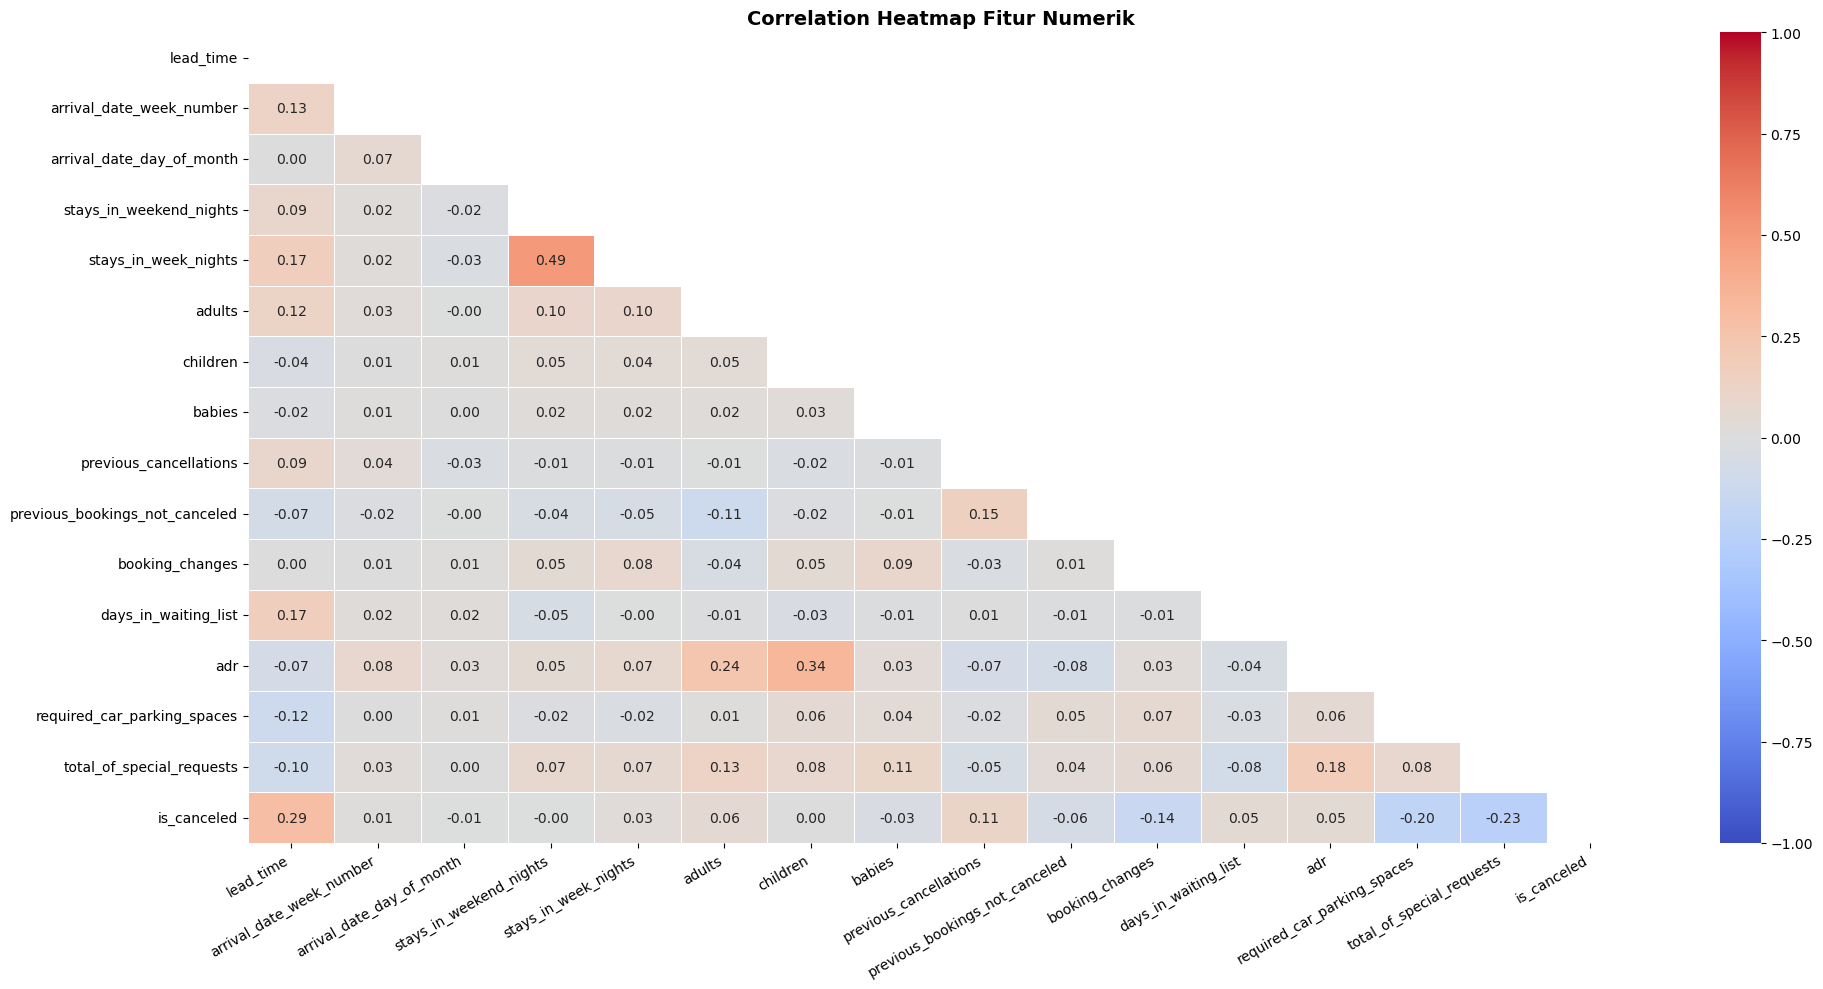

In [42]:
plt.figure(figsize=(20,10))

corr_matrix = df[num_cols + ['is_canceled']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})

plt.title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

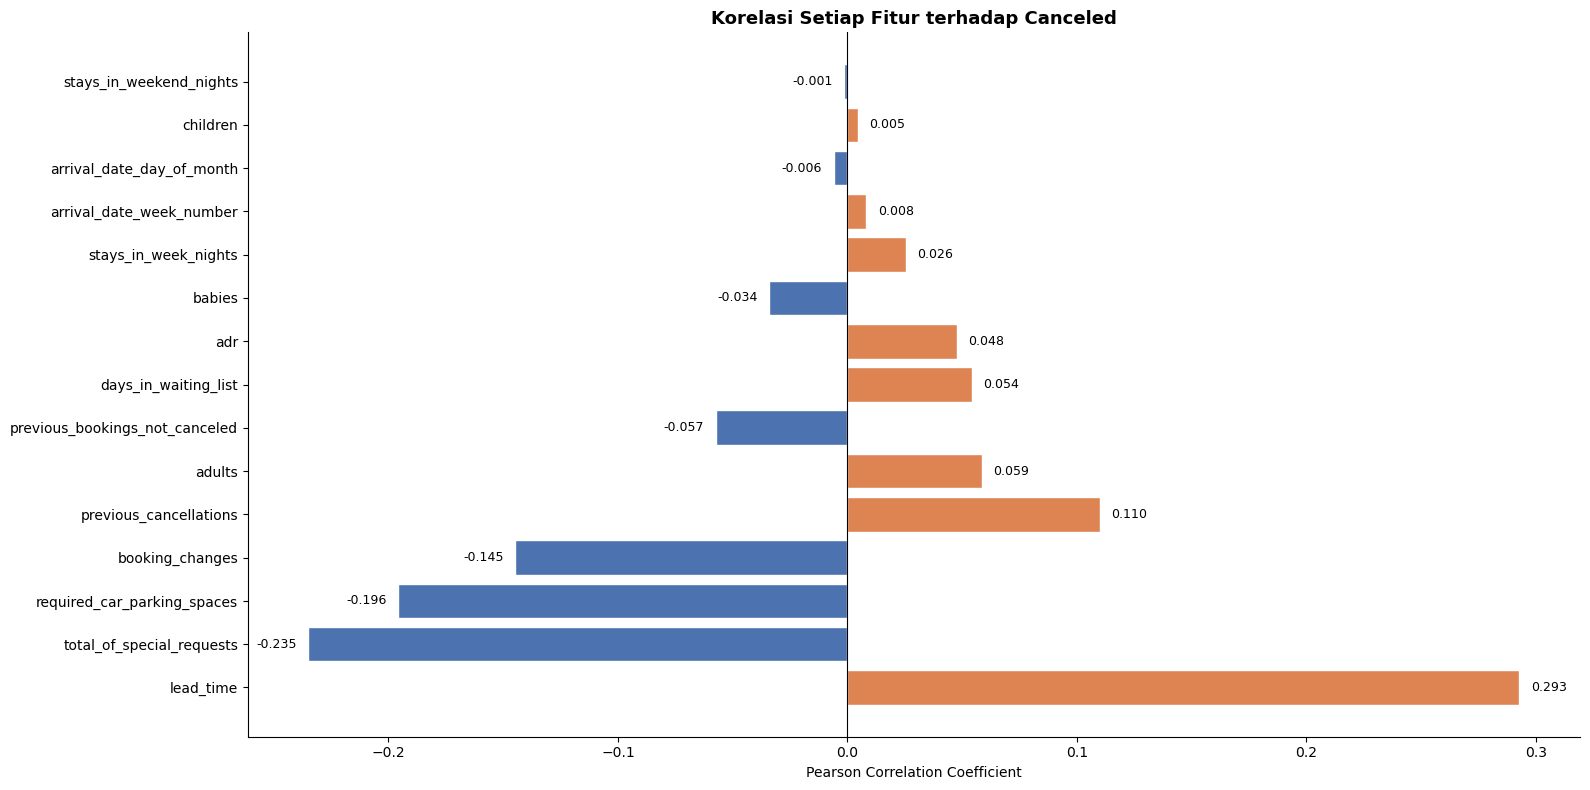

In [43]:
# Sort Highest Correlation Towards is_canceled
corr_with_churn = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

plt.figure(figsize=(16, 8))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_churn.values]
bars = plt.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_with_churn.values):
    plt.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.title('Korelasi Setiap Fitur terhadap Canceled', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Correlation & Multicollinearity Insight

- **`lead_time` memiliki korelasi positif terbesar dengan cancellation (r=0,293).** Artinya, booking dengan lead time lebih panjang cenderung lebih sering dibatalkan, konsisten dengan analisis lead-time bin.

- **`total_of_special_requests` (r=-0,235) dan `required_car_parking_spaces` (r=-0,196) memiliki korelasi negatif terbesar.** Nilai yang lebih tinggi pada kedua fitur cenderung berkaitan dengan kemungkinan cancellation yang lebih rendah.

- **`booking_changes` (r=-0,145) dan `previous_cancellations` (r=0,110) memiliki hubungan yang lebih lemah.** Fitur lainnya memiliki korelasi absolut di bawah 0,06.

- **Tidak terdapat korelasi antarf fitur numerik yang sangat tinggi pada heatmap ini.** Korelasi pasangan terbesar adalah `stays_in_week_nights` dengan `stays_in_weekend_nights` sekitar 0,46 serta `adr` dengan `children` sekitar 0,34.

- **Modeling Implication:** seluruh korelasi terhadap target masih tergolong lemah hingga moderat. Korelasi Pearson hanya menangkap hubungan linear dan tidak membuktikan kausalitas, sehingga feature importance tetap perlu dinilai dari model tervalidasi.


#### Multicollinearity Check — Variance Inflation Factor (VIF)

Heatmap korelasi hanya mengidentifikasi hubungan **pairwise** antarvariabel. Sebaliknya, **Variance Inflation Factor (VIF)** digunakan untuk mengevaluasi multikolinearitas yang melibatkan kombinasi lebih dari dua variabel secara simultan.

Pemeriksaan VIF menjadi penting apabila analisis dilanjutkan menggunakan **model linear**, seperti *Logistic Regression*, yang sensitif terhadap multikolinearitas. Dengan demikian, VIF membantu mengidentifikasi fitur-fitur yang memiliki keterkaitan linear tinggi dengan kombinasi fitur lainnya dan berpotensi memengaruhi stabilitas estimasi koefisien model.

In [44]:
X_vif = df[num_cols].dropna()
vif_df = pd.DataFrame()
vif_df['feature'] = num_cols
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
vif_df.sort_values('VIF', ascending=False)

,feature,VIF
5,adults,8.528606
12,adr,6.370443
1,arrival_date_week_number,4.521660
2,arrival_date_day_of_month,3.709195
4,stays_in_week_nights,3.649051
3,stays_in_weekend_nights,2.491960
0,lead_time,2.202985
14,total_of_special_requests,1.646778
6,children,1.209510
10,booking_changes,1.141451


#### VIF Insight

- **`adults` memiliki VIF tertinggi sebesar 8,54, diikuti `adr` sebesar 6,37.** Dengan rule of thumb VIF>5, keduanya perlu diperiksa lebih lanjut karena berpotensi memiliki ketergantungan linear dengan kombinasi fitur numerik lain.

- **`arrival_date_week_number` memiliki VIF 4,52**, sedangkan `arrival_date_day_of_month`, `stays_in_week_nights`, `stays_in_weekend_nights`, dan `lead_time` berada pada rentang 2,20–3,71. Fitur lainnya memiliki VIF di bawah 2.

- **Hasil VIF ini berbeda dari korelasi pairwise** karena VIF mengukur hubungan satu fitur terhadap gabungan seluruh fitur lain. Namun, kode saat ini belum menambahkan konstanta/intercept, sehingga nilai VIF sebaiknya dihitung ulang dengan constant sebelum keputusan penghapusan fitur dibuat.

- **Modeling Implication:** jangan langsung menghapus `adults` atau `adr` hanya dari satu hasil VIF. Bandingkan stabilitas koefisien dan performa cross-validation pada model linear; model tree-based relatif tidak sensitif terhadap multikolinearitas, meskipun redundansi tetap dapat membagi feature importance.


### **1.4.2 Pairplot Selected Feature vs Target**

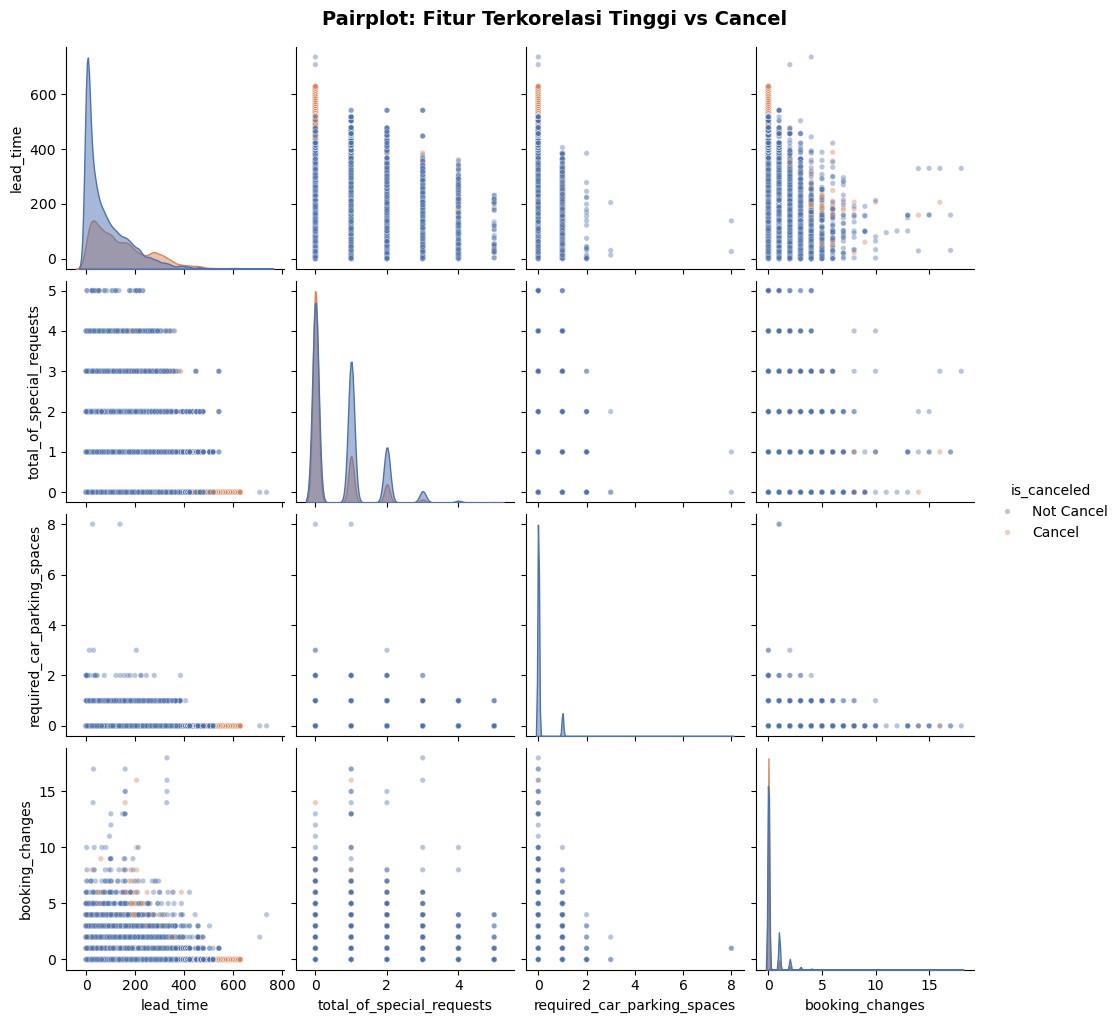

In [45]:
top_features = ['lead_time', 'total_of_special_requests', 'required_car_parking_spaces', 'booking_changes', 'is_canceled']

pair_df = df[top_features].copy()
pair_df['is_canceled'] = pair_df['is_canceled'].map({0: 'Not Cancel', 1: 'Cancel'})

g = sns.pairplot(pair_df, hue='is_canceled', palette={'Not Cancel': '#4C72B0', 'Cancel': '#DD8452'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'fill': True, 'alpha': 0.5})

g.figure.suptitle('Pairplot: Fitur Terkorelasi Tinggi vs Cancel',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

#### Pairplot: Selected Numerical Features vs Cancellation Insight

- **Panel diagonal menunjukkan bahwa `lead_time` memiliki pemisahan distribusi paling jelas.** Canceled memiliki distribusi yang lebih lebar dan bergeser ke nilai lebih tinggi, sedangkan Not Canceled terkonsentrasi pada lead time rendah.

- **`total_of_special_requests` dan `required_car_parking_spaces` bersifat diskrit dan terkonsentrasi pada sedikit nilai.** Distribusi kedua kelas tumpang tindih, tetapi Not Canceled relatif lebih banyak pada nilai fitur yang lebih tinggi. Interpretasi lebih tepat menggunakan cancellation rate per kategori daripada tinggi KDE saja.

- **`booking_changes` menunjukkan tumpang tindih besar**, sehingga pairplot tidak memberikan bukti pemisahan kelas yang kuat untuk fitur ini.

- **Scatterplot off-diagonal mengalami overplotting** karena menggunakan 119.205 observasi dan beberapa fitur memiliki rentang diskrit yang sempit. Pola hubungan antarf fitur sulit dibaca dari titik mentah.

- **Modeling Implication:** gunakan sampling seimbang, jitter, hexbin, atau 2D density untuk visualisasi lanjutan. Pairplot bersifat eksploratif dan tidak digunakan sebagai bukti feature importance.
